# Data import

In [2]:
import scanpy as sc
adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/After_Clustering.h5ad")

In [3]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

include_samples = {
'UA_Endo11460962_FX1170', 'UA_Endo11596522_FX1104', 'UA_Endo12061705_FX1129', 'UA_Endo12296823_EX0795', 'UA_Endo12296823_FX1119', 
'UA_Endo12296824_FX1125', 'UA_Endo12449301_FX1136', 'UA_Endo11460961_FX1097', 'UA_Endo12061415_FX1158', 'UA_Endo12061704_FX9024', 
'UA_Endo12269810_FX0033', 'UA_Endo12604667_FX1130', 'UA_Endo12865966_FX1223', 'UA_Endo10281925_FX1101', 'UA_Endo10281926_FX1101', 
'UA_Endo11282193_EX0540', 'UA_Endo11596521_FX1236', 'UA_Endo11596522_FX9005', 'UA_Endo12449299_EX0288', 'UA_Endo12449300_FX9027', 
'UA_Endo12449301_FX1150', 'UA_Endo11173480_FX0052', 'UA_Endo12449298_FX1160'    
}

adata = adata[adata.obs['Sample name'].isin(include_samples)].copy()

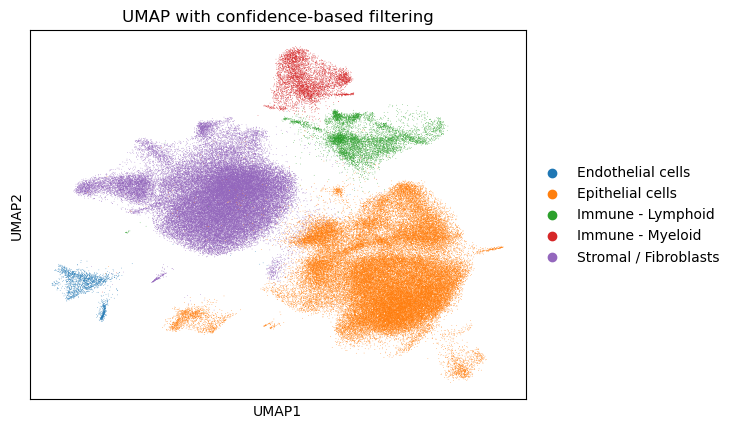

In [4]:
sc.pl.umap(
    adata,
    color='celltype_grouped',
    title='UMAP with confidence-based filtering')

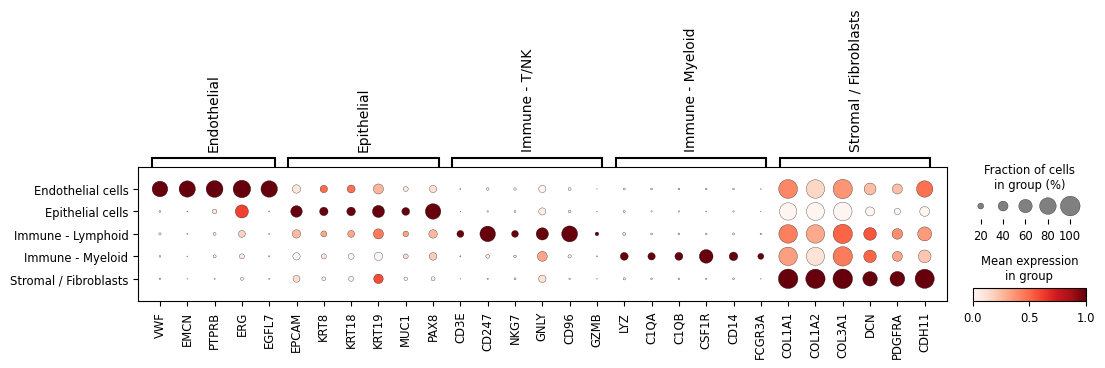

In [5]:
group_markers = {
"Endothelial": ["VWF","EMCN","PTPRB","ERG","EGFL7"],
"Epithelial": ["EPCAM","KRT8","KRT18","KRT19","MUC1","PAX8"],
"Immune - T/NK": ["CD3E","CD247","NKG7","GNLY","CD96","GZMB"],
"Immune - Myeloid": ["LYZ","C1QA","C1QB","CSF1R","CD14","FCGR3A"],
"Stromal / Fibroblasts": ["COL1A1","COL1A2","COL3A1","DCN","PDGFRA","CDH11"]
}

existing_genes = {
    cat: [gene for gene in genes if gene in adata.var_names]
    for cat, genes in group_markers.items()
}

existing_genes = {cat: genes for cat, genes in existing_genes.items() if genes}

sc.pl.dotplot(
    adata,
    var_names=existing_genes,
    groupby="celltype_grouped",
    standard_scale="var")

/tmp/ipykernel_3584606/2410606681.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Cycle','celltype_grouped'])
/tmp/ipykernel_3584606/2410606681.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Cycle','celltype_grouped'])


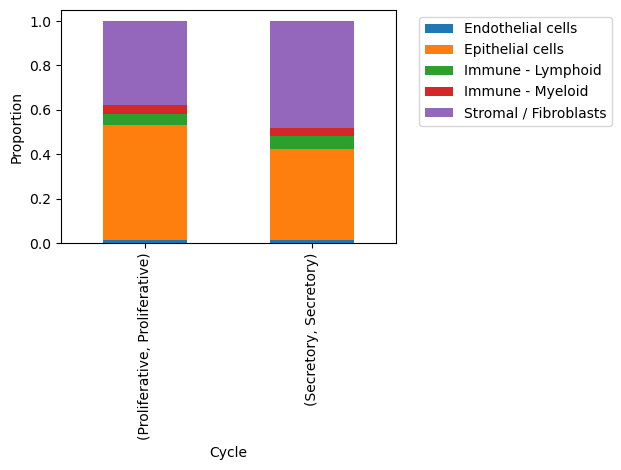

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = adata.obs[['Cycle','celltype_grouped']].copy()

prop = (
    df.groupby(['Cycle','celltype_grouped'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

prop.plot(kind='bar', stacked=True)

plt.xlabel('Cycle')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3584606/4036351275.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age group','celltype_grouped'])
/tmp/ipykernel_3584606/4036351275.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age group','celltype_grouped'])


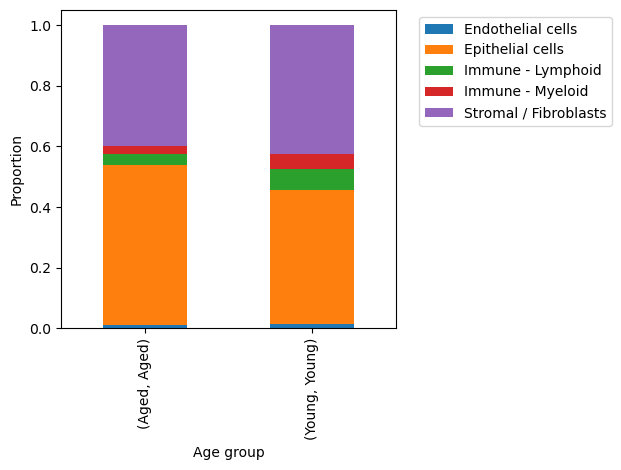

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = adata.obs[['Age group','celltype_grouped']].copy()

prop = (
    df.groupby(['Age group','celltype_grouped'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

prop.plot(kind='bar', stacked=True)

plt.xlabel('Age group')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

Processing genesets:  20%|██        | 1/5 [00:00<00:02,  1.39it/s]

Error processing Stromal / Fibroblasts for PanglaoDB_Augmented_2021: Error analyzing gene list
Error processing Stromal / Fibroblasts for CellMarker_2024: Error analyzing gene list
Error processing Immune - Lymphoid for CellMarker_2024: Error analyzing gene list
Error processing Stromal / Fibroblasts for CellMarker_Augmented_2021: Error analyzing gene list
Error processing Immune - Myeloid for CellMarker_Augmented_2021: Error analyzing gene list
Error processing Immune - Myeloid for CellMarker_2024: Error analyzing gene list
Error processing Epithelial cells for PanglaoDB_Augmented_2021: Error analyzing gene list
Error processing Immune - Myeloid for PanglaoDB_Augmented_2021: Error analyzing gene list
Error processing Immune - Lymphoid for PanglaoDB_Augmented_2021: Error analyzing gene list
Error processing Immune - Lymphoid for CellMarker_Augmented_2021: Error analyzing gene list


Processing genesets: 15it [00:04,  3.44it/s]                      


Trying to re-request...
Epithelial cells with PanglaoDB_Augmented_2021 completed!
Immune - Lymphoid with CellMarker_2024 completed!
Immune - Lymphoid with CellMarker_Augmented_2021 completed!
Immune - Lymphoid with PanglaoDB_Augmented_2021 completed!
Immune - Myeloid with CellMarker_2024 completed!
Immune - Myeloid with CellMarker_Augmented_2021 completed!
Immune - Myeloid with PanglaoDB_Augmented_2021 completed!
Stromal / Fibroblasts with CellMarker_2024 completed!
Stromal / Fibroblasts with CellMarker_Augmented_2021 completed!
Stromal / Fibroblasts with PanglaoDB_Augmented_2021 completed!


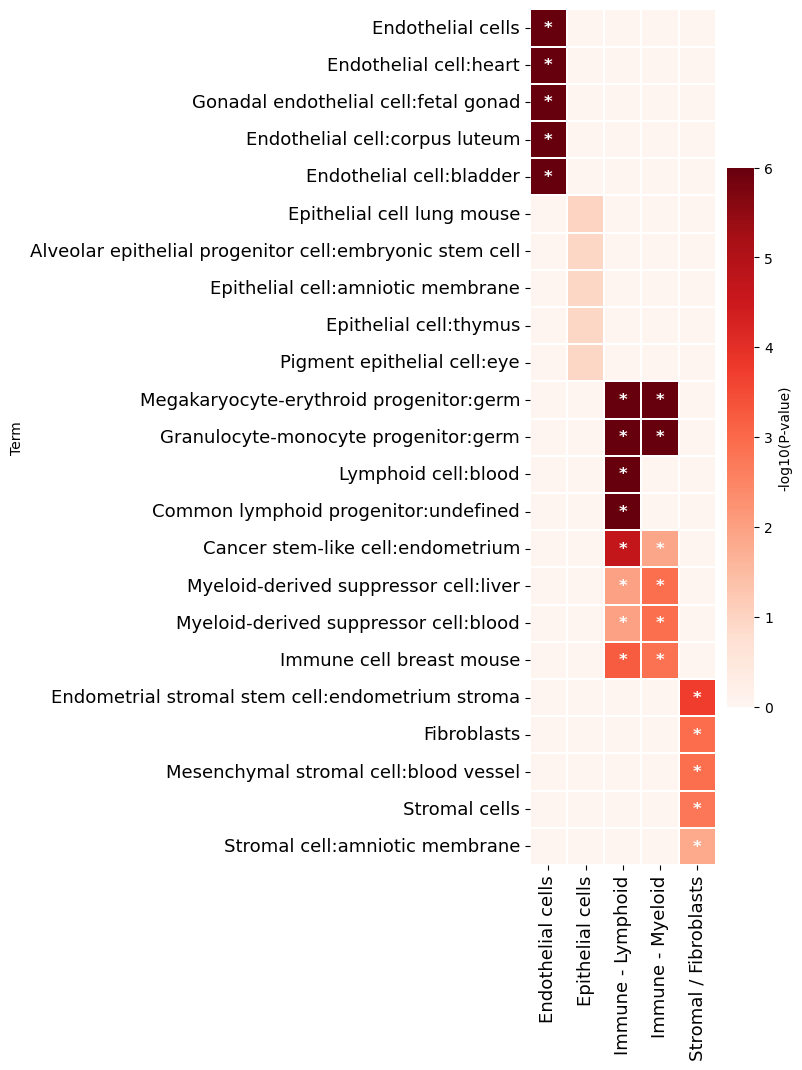

In [8]:
import pandas as pd
import scanpy as sc
import sys
sys.path.append("/home/Data_Drive_8TB/kykim/QED")
from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sc.tl.rank_genes_groups(adata, 'celltype_grouped', method="wilcoxon",use_raw =False)
sc.tl.dendrogram(adata, groupby='celltype_grouped')

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

up_dict = {}
down_dict = {}

for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로
df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())
sc.tl.dendrogram(adata, groupby='celltype_grouped')

import pandas as pd
import scanpy as sc

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)
up_dict = {}
down_dict = {}
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"
    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로
df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

import pandas as pd

class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}

dblist = ['CellMarker_2024','CellMarker_Augmented_2021',"PanglaoDB_Augmented_2021"]

df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)

aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)

df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()


from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns

    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    # 상위 n개 Term 추출
    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()

    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())

    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)

    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())

    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = sorted(df[group_by].unique())

    for group in group_order_for_plot:
        current_group_terms = (
            df_ranked_per_group[df_ranked_per_group[group_by] == group]
            .sort_values(order_by)
        )
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number])
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]

    else:
        try:
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
            pass


    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

df_filtered = df[
    df.apply(
        lambda x: any(t in x['Term'] for t in str(x['Leiden']).split()),
        axis=1)]

df_sorted = df_filtered.sort_values(by='Rank')

fig, ax = heatmap_with_groupwise_ordering(
    df= df_sorted,
    n=5,
    group_by='Leiden',
    order_by="Adjusted p-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
    enable_highlight_columns=False)

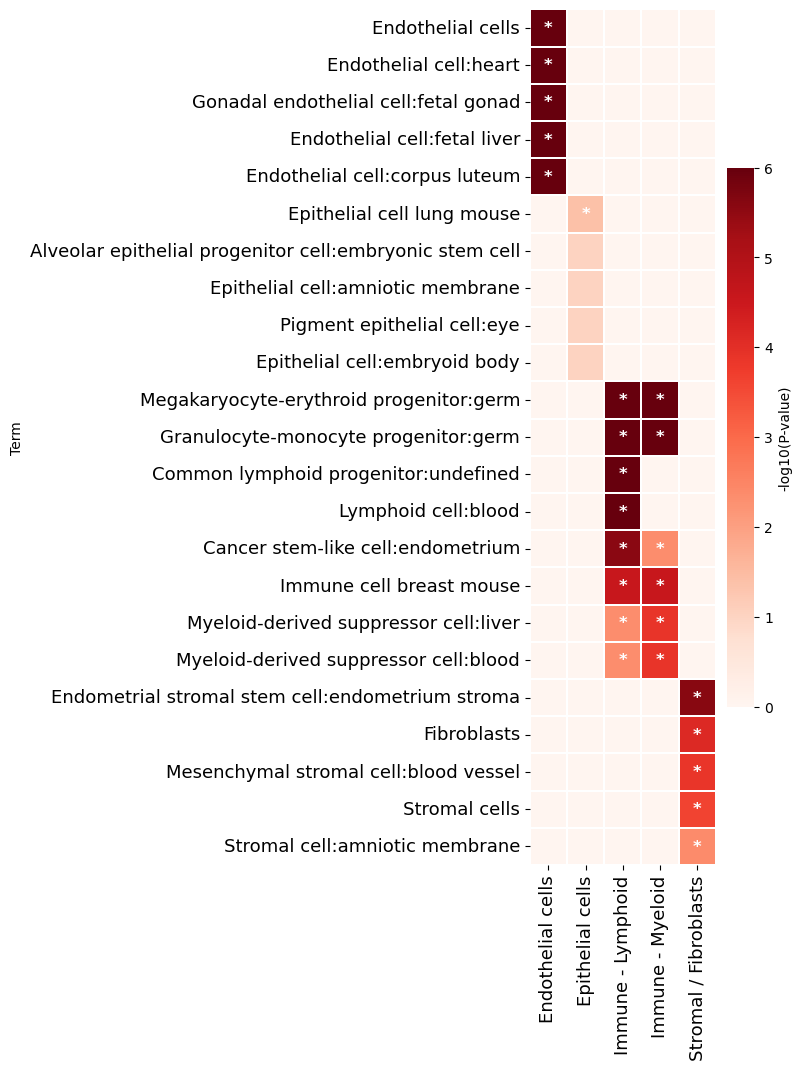

In [9]:
fig, ax = heatmap_with_groupwise_ordering(
    df= df_sorted,
    n=5,
    group_by='Leiden',
    order_by="P-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
    enable_highlight_columns=False)

In [10]:
adata.write("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Total_selected.h5ad")

# Epithelial subtype (New)

In [11]:
import scanpy as sc
adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Total_selected.h5ad")

Epithelial = adata[adata.obs['celltype_grouped'] == 'Epithelial cells'].copy()

In [12]:
import scanpy as sc

adata_source = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/after_QC_Before_HVG_raw.h5ad")

common_barcodes = Epithelial.obs_names.intersection(adata_source.obs_names)

Epithelial = Epithelial[common_barcodes].copy()
adata_source = adata_source[common_barcodes].copy()

adata_source = adata_source[Epithelial.obs_names].copy()

Epithelial._X = adata_source.X.copy()
Epithelial._var = adata_source.var.copy()
Epithelial._n_vars = adata_source.n_vars

In [13]:
Epithelial.layers['counts'] = Epithelial.X.copy()

In [14]:
sc.pp.normalize_total(Epithelial)
sc.pp.log1p(Epithelial)

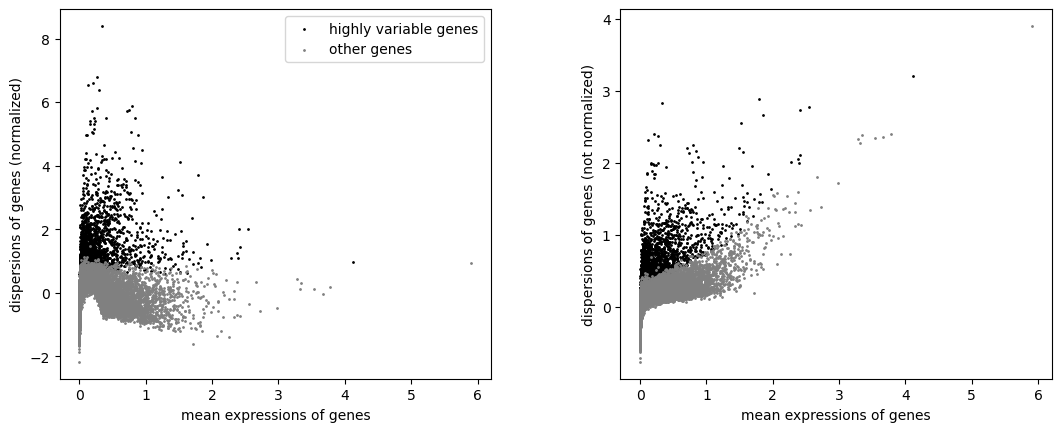

In [15]:
sc.pp.highly_variable_genes(Epithelial, n_top_genes=2000, batch_key="Sample name")
sc.pl.highly_variable_genes(Epithelial)
Epithelial = Epithelial[:, Epithelial.var['highly_variable']].copy()

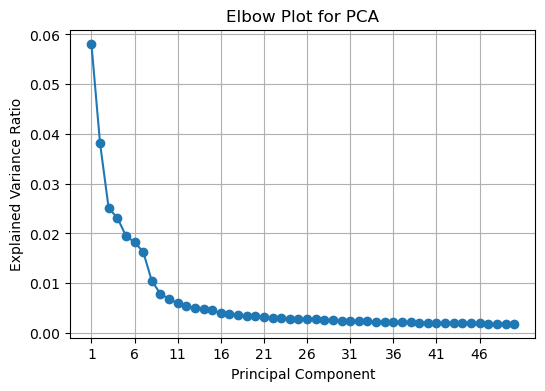

In [16]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(Epithelial)
explained_variance_ratio = Epithelial.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

In [17]:
sc.tl.pca(Epithelial, n_comps=31, svd_solver='arpack')

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which ma

Epoch 256/400:  64%|██████▍   | 256/400 [19:14<10:49,  4.51s/it, v_num=1, train_loss_step=1.13e+3, train_loss_epoch=1.15e+3]
Monitored metric elbo_validation did not improve in the last 5 records. Best score: 1159.445. Signaling Trainer to stop.


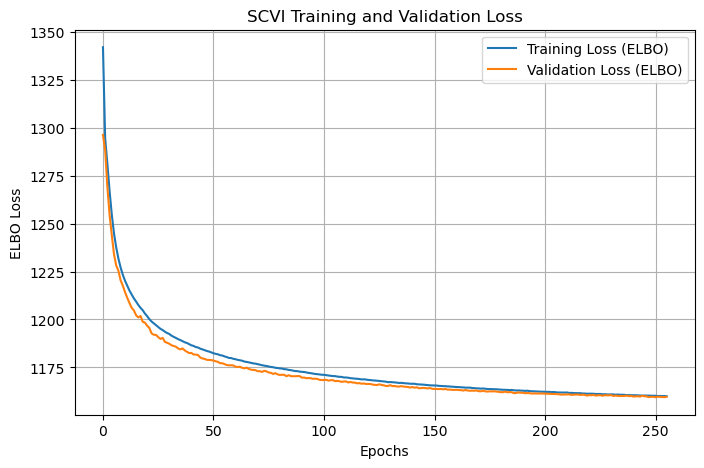

In [19]:
import scvi 
import matplotlib.pyplot as plt

scvi.model.SCVI.setup_anndata(Epithelial, layer="counts", batch_key="Sample name")
vae = scvi.model.SCVI(Epithelial, n_layers=2, n_latent=30, gene_likelihood="nb")

vae.train(max_epochs=400, early_stopping=True, early_stopping_patience=5)

train_loss = vae.history["elbo_train"]
val_loss = vae.history["elbo_validation"]
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss (ELBO)")
plt.plot(val_loss, label="Validation Loss (ELBO)")
plt.xlabel("Epochs")
plt.ylabel("ELBO Loss")
plt.title("SCVI Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

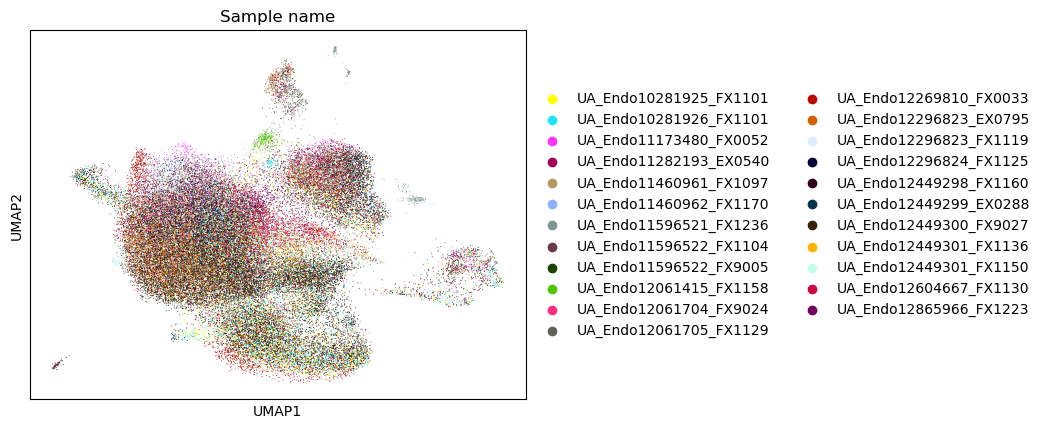

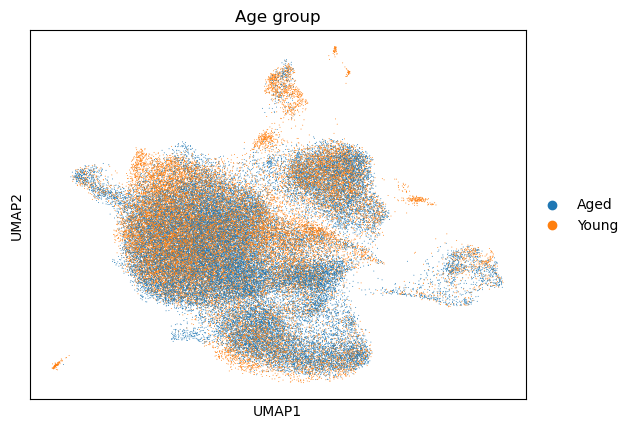

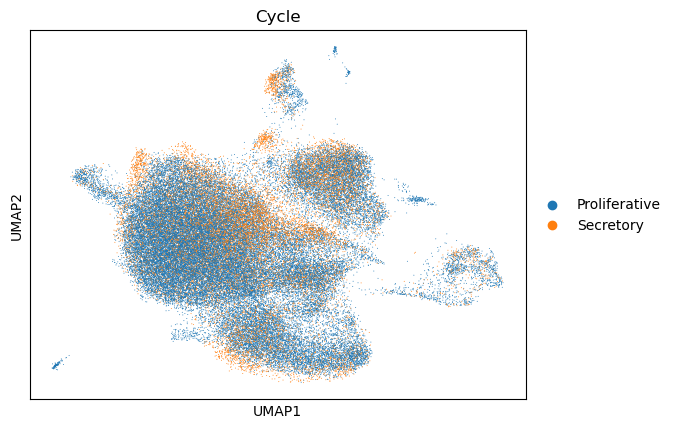

In [20]:
Epithelial.obsm["X_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(Epithelial, use_rep = 'X_scVI')
sc.tl.umap(Epithelial)

sc.pl.umap(Epithelial, color=["Sample name"])
sc.pl.umap(Epithelial, color=["Age group"])
sc.pl.umap(Epithelial, color=["Cycle"])

In [21]:
del Epithelial.varm['PCs']
del Epithelial.layers['counts']

In [22]:
Epithelial.write("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Epithelial.h5ad")

In [23]:
import scanpy as sc

adata_source = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/after_QC_Before_HVG_raw.h5ad")

common_barcodes = Epithelial.obs_names.intersection(adata_source.obs_names)

Epithelial = Epithelial[common_barcodes].copy()
adata_source = adata_source[common_barcodes].copy()

adata_source = adata_source[Epithelial.obs_names].copy()

Epithelial._X = adata_source.X.copy()
Epithelial._var = adata_source.var.copy()
Epithelial._n_vars = adata_source.n_vars

sc.pp.normalize_total(Epithelial)
sc.pp.log1p(Epithelial)

for res in [0.50 ,1.00, 1.50]:
    sc.tl.leiden(
        Epithelial, key_added=f"leiden_res_{res:4.2f}", resolution=res, 
        flavor="igraph"
    )

Cluster 0: ['TMEM101', 'ARHGAP26', 'LINC01541', 'MAML3', 'SMAD9', 'PAPSS1', 'UBE2D2', 'NPAS3', 'MTCL1', 'AC024230.1', 'POC1B', 'KIF13B', 'PCAT1', 'MCC', 'KIAA1324', 'LINC00621', 'MAGI1', 'AL365295.1', 'PRKAG2', 'ANAPC4']
Cluster 1: ['DCDC2', 'SHROOM3', 'KCTD1', 'GDA', 'PTPRM', 'SOX5', 'DST', 'MAML2', 'LGR5', 'VTCN1', 'PAPOLA', 'DAB1', 'LINC00639', 'MECOM', 'SOX6', 'FGFR2', 'CD47', 'ERBB4', 'ADGRL2', 'CADM1']
Cluster 2: ['PRKAG2', 'TMEM101', 'KIAA1324', 'DNAJC10', 'ANAPC4', 'PCAT1', 'NPAS3', 'MTCL1', 'ST3GAL5', 'MCC', 'AC024230.1', 'CPM', 'PPM1H', 'KMO', 'ENPP3', 'SLC46A2', 'AC078845.1', 'MAGI1', 'ERG', 'LINC02814']
Cluster 3: ['GREM2', 'TMEM101', 'NPAS3', 'CNTN5', 'CPM', 'AC246817.1', 'SGCD', 'VWA8', 'LINC00621', 'KMO', 'LINC01541', 'ADAMTS6', 'PGR', 'FNDC3B', 'AC120193.1', 'EYA2', 'KIAA1324', 'TRMT9B', 'MCC', 'AC079465.1']
Cluster 4: ['RPL41', 'RPLP1', 'TMSB10', 'EEF1A1', 'TMSB4X', 'B2M', 'RPL3', 'RPL11', 'PTMA', 'RPL8', 'MYL6', 'ACTB', 'RPS27', 'RPS4X', 'RPL13', 'RPL30', 'RPS27A', 'R

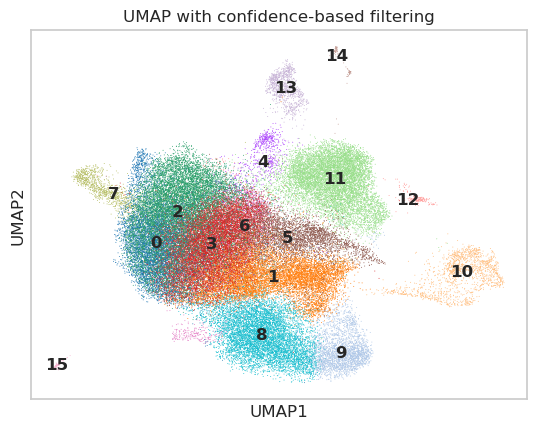

In [97]:
import scanpy as sc
sc.tl.rank_genes_groups(Epithelial, groupby='leiden_res_1.00', method='t-test')  # 또는 'wilcoxon'
top_genes = {}
groups = Epithelial.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들
for group in groups:
    genes = Epithelial.uns['rank_genes_groups']['names'][group][:20]
    top_genes[group] = genes.tolist()


for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")
sc.pl.umap(
    Epithelial,
    color='leiden_res_1.00',
    title='UMAP with confidence-based filtering',
    legend_loc='on data')

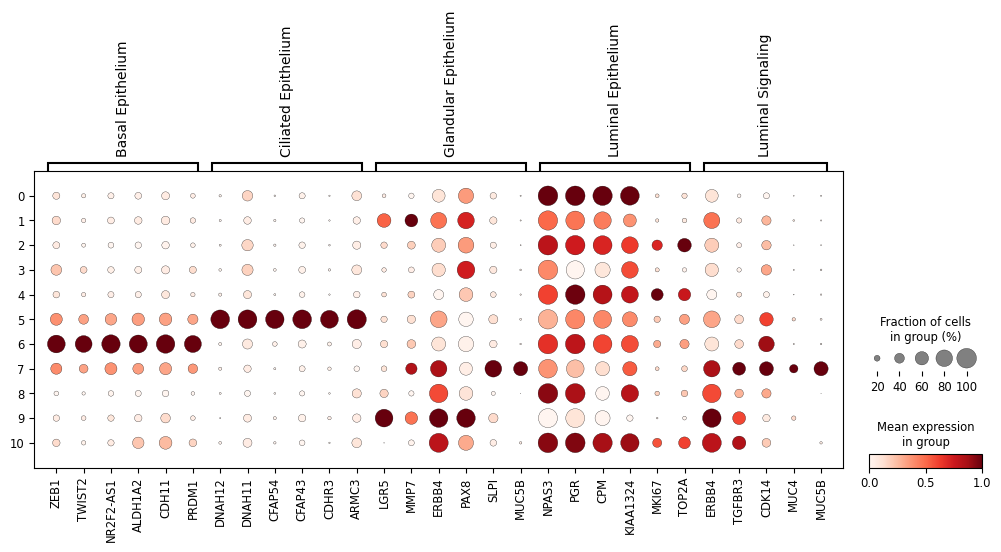

In [37]:
Epithelial_subtype_markers_human = {
    "Basal Epithelium": [
        "ZEB1", "TWIST2", "NR2F2-AS1", "ALDH1A2", "CDH11", "PRDM1"
    ],
    "Ciliated Epithelium": [
        "DNAH12", "DNAH11", "CFAP54", "CFAP43", "CDHR3", "ARMC3"
    ],
    "Glandular Epithelium": [
        "LGR5", "MMP7", "ERBB4", "PAX8", "SLPI", "MUC5B"
    ],
    "Luminal Epithelium": [
        "NPAS3", "PGR", "CPM", "KIAA1324", "MKI67", "TOP2A"
    ],
        "Luminal Signaling": ["ERBB4", "TGFBR3", "CDK14", "MUC4","MUC5B"]
}

existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in Epithelial.var_names]
    for subtype, genes in Epithelial_subtype_markers_human.items()}

sc.pl.dotplot(
    Epithelial,
    var_names=existing_subtype_markers,
    groupby="leiden_res_0.50",
    standard_scale="var",
    dendrogram=False)

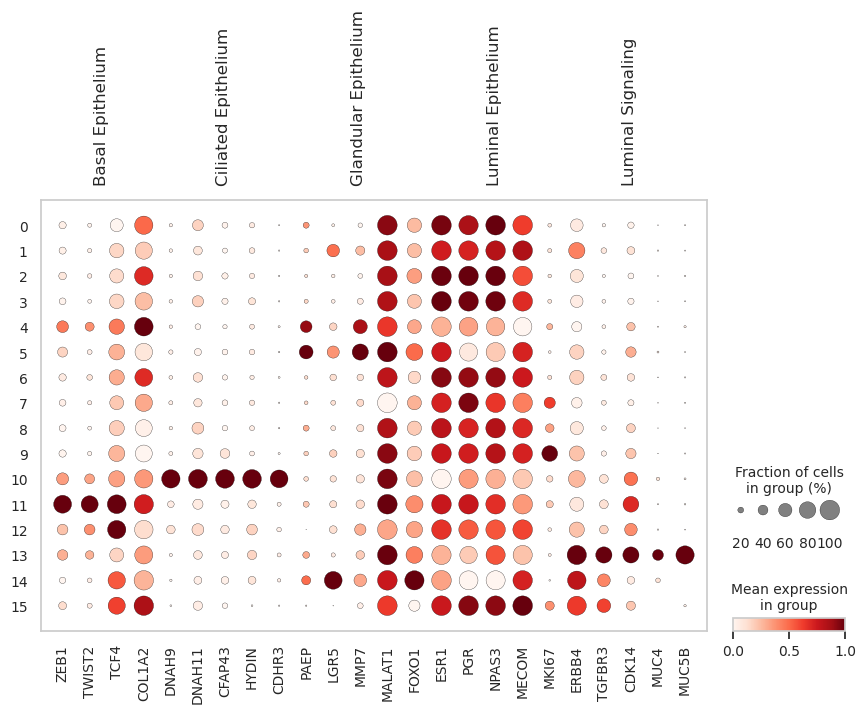

In [91]:
import scanpy as sc

Epithelial_subtype_markers_human = {
    "Basal Epithelium": [
        "ZEB1", "TWIST2", "TCF4", "COL1A2",
    ],
    "Ciliated Epithelium": [
        "DNAH9", "DNAH11", "CFAP43", "HYDIN", "CDHR3",
    ],
    "Glandular Epithelium": [
        "PAEP", "LGR5", "MMP7", "MALAT1", "FOXO1",
    ],
    "Luminal Epithelium": [
        "ESR1", "PGR", "NPAS3", "MECOM", "MKI67",
    ],
    "Luminal Signaling": ["ERBB4", "TGFBR3", "CDK14", "MUC4","MUC5B"]
}
existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in Epithelial.var_names]
    for subtype, genes in Epithelial_subtype_markers_human.items()}

sc.pl.dotplot(
    Epithelial,
    var_names=existing_subtype_markers,
    groupby="leiden_res_1.00",
    standard_scale="var",
    dendrogram=False)

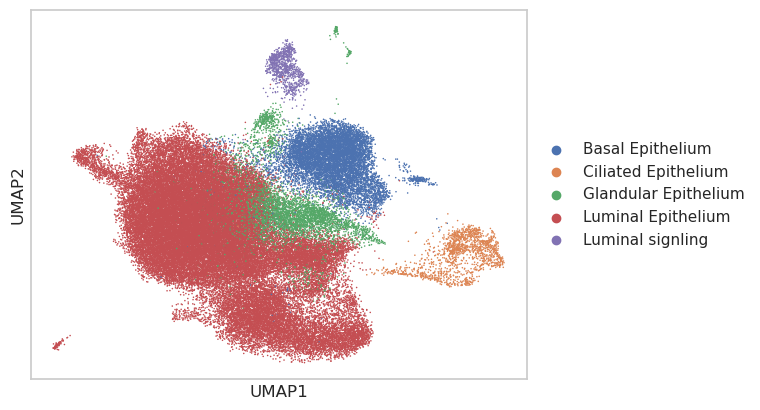

In [102]:
import scanpy as sc

cluster_to_group = {
    0: "Luminal Epithelium",
    1: "Luminal Epithelium",
    2: "Luminal Epithelium",
    3: "Luminal Epithelium",
    4: "Glandular Epithelium", #
    5: "Glandular Epithelium",
    6: "Luminal Epithelium",
    7: "Luminal Epithelium",
    8: "Luminal Epithelium",
    9: "Luminal Epithelium",
    10:"Ciliated Epithelium",
    11:"Basal Epithelium",
    12:"Basal Epithelium",
    13:"Luminal signling",
    14:'Glandular Epithelium',
    15:"Luminal Epithelium"
}
Epithelial.obs["subtype"] = Epithelial.obs["leiden_res_1.00"].astype(int).map(cluster_to_group)
sc.pl.umap(
    Epithelial,
    color='subtype',
    title='',
    s = 5
)

In [98]:
import scanpy as sc
sc.tl.rank_genes_groups(Epithelial, groupby='subtype', method='t-test')  # 또는 'wilcoxon'
top_genes = {}
groups = Epithelial.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들
for group in groups:
    genes = Epithelial.uns['rank_genes_groups']['names'][group][:10]
    top_genes[group] = genes.tolist()


for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")

Cluster Basal: ['AUTS2', 'LINC02163', 'DACH1', 'PHF21B', 'SNTB1', 'KIZ', 'ATXN1', 'PARD3B', 'BCL2', 'APP']
Cluster Basal Epithelium: ['NR2F2-AS1', 'LSAMP', 'CDH11', 'NLGN1', 'KCNIP4', 'AUTS2', 'DLC1', 'ALDH1A2', 'DPP6', 'LDB2']
Cluster Ciliated Epithelium: ['DNAH12', 'ARMC3', 'CFAP54', 'CFAP43', 'CFAP299', 'STK33', 'LRRIQ1', 'DNAH7', 'HYDIN', 'DNAH9']
Cluster Glandular Epithelium: ['MMP7', 'PAEP', 'SOX4', 'CP', 'PREX2', 'SYNE2', 'CFI', 'TSHZ2', 'INPP4B', 'TCIM']
Cluster Luminal Epithelium: ['TMEM101', 'NPAS3', 'CPM', 'LINC01541', 'CNTN5', 'STX18', 'SMAD9', 'LINC02814', 'POC1B', 'VWA8']
Cluster Luminal signling: ['THSD4', 'ERBB4', 'MUC5B', 'PTPRD', 'EFNA5', 'IGF2BP2', 'SLIT2', 'TGFBR3', 'BMERB1', 'SLPI']


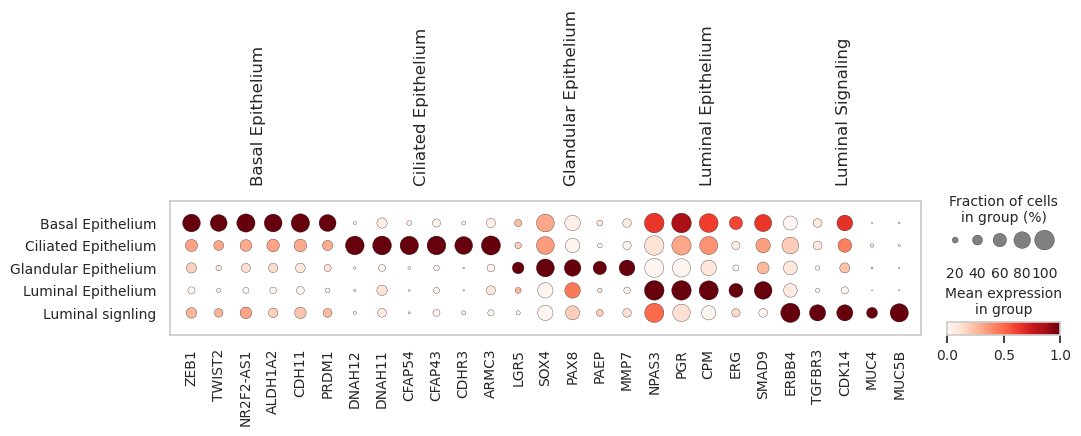

In [124]:
Epithelial_subtype_markers_human = {
    "Basal Epithelium": [
        "ZEB1", "TWIST2", "NR2F2-AS1", "ALDH1A2", "CDH11", "PRDM1"
    ],
    "Ciliated Epithelium": [
        "DNAH12", "DNAH11", "CFAP54", "CFAP43", "CDHR3", "ARMC3"
    ],
    "Glandular Epithelium": [
        "LGR5", "LGP5", "SOX4", "PAX8", "PAEP", "MMP7"
    ],
    "Luminal Epithelium": [
        "NPAS3", "PGR", "CPM", "ERG", "SMAD9"
    ],
    "Luminal Signaling": ["ERBB4", "TGFBR3", "CDK14", "MUC4","MUC5B"]}

existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in Epithelial.var_names]
    for subtype, genes in Epithelial_subtype_markers_human.items()}

sc.pl.dotplot(
    Epithelial,
    var_names=existing_subtype_markers,
    groupby="subtype",
    standard_scale="var",
    dendrogram=False)

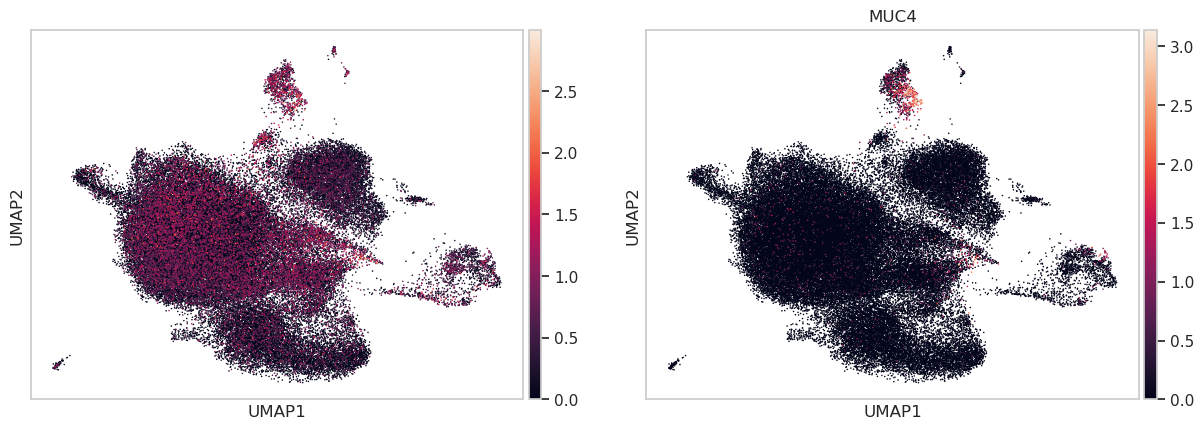

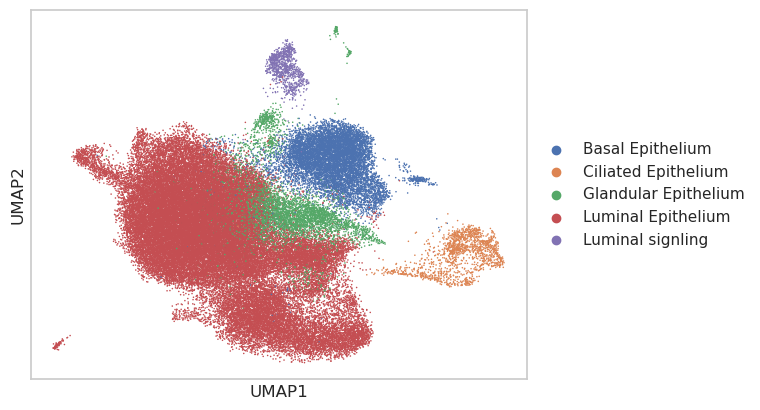

In [101]:
sc.pl.umap(
    Epithelial,
    color=['MUC1','MUC4'],
    title='',
    s = 5
)
sc.pl.umap(
    Epithelial,
    color='subtype',
    title='',
    s = 5
)

In [125]:
# del Epithelial.varm['PCs']
# del Epithelial.layers['counts']

Epithelial.write("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Epithelial.h5ad")

In [63]:
import scanpy as sc
Epithelial = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Epithelial.h5ad")

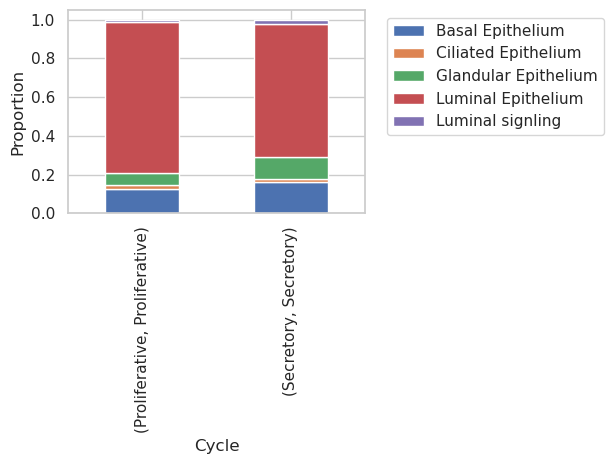

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

df = Epithelial.obs[['Cycle','subtype']].copy()

prop = (
    df.groupby(['Cycle','subtype'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

prop.plot(kind='bar', stacked=True)

plt.xlabel('Cycle')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

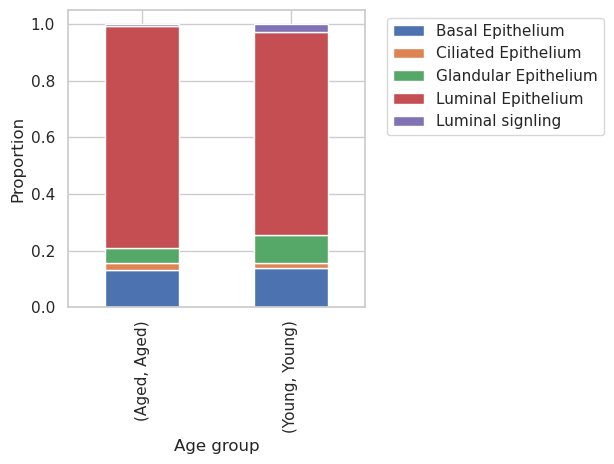

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

df = Epithelial.obs[['Age group','subtype']].copy()

prop = (
    df.groupby(['Age group','subtype'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

prop.plot(kind='bar', stacked=True)

plt.xlabel('Age group')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

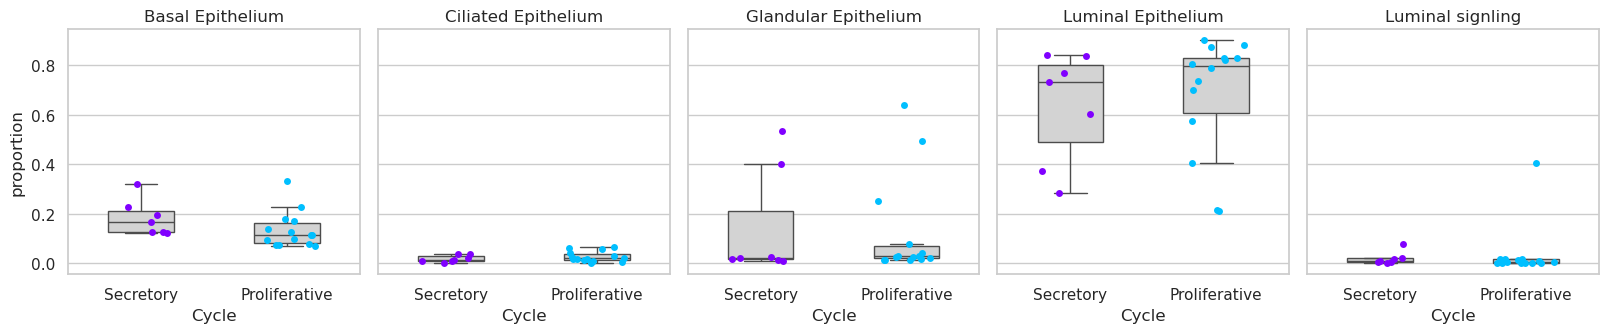

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
import warnings
import scanpy as sc

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

clin_palette = {
    'Secretory': '#8000ff',
    'Proliferative': '#00bfff',
    'Menstrual': '#ff8c00'
}

Epithelial.obs['Each mouse'] = Epithelial.obs['Individual']

adata_filtered = Epithelial[Epithelial.obs['Organism part'] != 'spleen'].copy()
adata_filtered = adata_filtered[
    adata_filtered.obs['Cycle'].isin(['Secretory','Proliferative'])
]

group_order = ['Secretory', 'Proliferative']

subtypes = sorted(adata_filtered.obs['subtype'].dropna().unique())

def normalize_mouse(df):
    total = df['count'].sum()
    df['proportion'] = df['count'] / total if total > 0 else 0
    return df

mouse_props_list = []

for (mouse, cycle), grp_df in adata_filtered.obs.groupby(['Each mouse','Cycle']):
    count_df = grp_df.groupby('subtype').size().reset_index(name='count')
    count_df['Each mouse'] = mouse
    count_df['Cycle'] = cycle
    mouse_props_list.append(normalize_mouse(count_df))

mouse_props = pd.concat(mouse_props_list, ignore_index=True)

n_rows, n_cols = 1, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.25*n_cols, 3.5*n_rows), sharey=True)

axes = axes.flatten()

for i, subtype in enumerate(subtypes):
    ax = axes[i]

    data_sub = mouse_props[mouse_props['subtype'] == subtype]

    sns.boxplot(
        x='Cycle', y='proportion', data=data_sub, ax=ax,
        order=group_order,
        boxprops={'facecolor': 'lightgray'},
        fliersize=0,
        width=0.45
    )

    for cond in data_sub['Cycle'].unique():
        sub_df = data_sub[data_sub['Cycle'] == cond]
        sns.stripplot(
            x='Cycle', y='proportion', data=sub_df,
            color=clin_palette.get(cond, 'black'),
            jitter=0.2,
            size=5,
            ax=ax,
            order=group_order
        )

    pairs = [('Secretory','Proliferative'),
             ('Secretory','Menstrual'),
             ('Proliferative','Menstrual')]

    for j, (g1, g2) in enumerate(pairs):
        v1 = data_sub[data_sub['Cycle'] == g1]['proportion']
        v2 = data_sub[data_sub['Cycle'] == g2]['proportion']

        if len(v1) > 0 and len(v2) > 0:
            _, p = ranksums(v1, v2)
            if p < 0.05:
                x1, x2 = group_order.index(g1), group_order.index(g2)
                y = 1.05 + j * 0.05
                ax.plot([x1, x1, x2, x2], [y, y+0.01, y+0.01, y], c='red')
                ax.text((x1+x2)/2, y+0.015, "*", ha='center', color='red')

    ax.set_title(subtype)

for j in range(len(subtypes), n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [106]:
results = []

for subtype in subtypes:
    data_sub = mouse_props[mouse_props['subtype'] == subtype]

    for g1, g2 in [
        ('Secretory','Proliferative'),
        ('Secretory','Menstrual'),
        ('Proliferative','Menstrual')
    ]:
        v1 = data_sub[data_sub['Cycle'] == g1]['proportion']
        v2 = data_sub[data_sub['Cycle'] == g2]['proportion']

        if len(v1) > 0 and len(v2) > 0:
            _, p = ranksums(v1, v2)
            results.append([subtype, g1, g2, p])

pval_df = pd.DataFrame(results, columns=['subtype','group1','group2','pvalue'])

print(pval_df)

                subtype     group1         group2    pvalue
0      Basal Epithelium  Secretory  Proliferative  0.100734
1   Ciliated Epithelium  Secretory  Proliferative  0.332116
2  Glandular Epithelium  Secretory  Proliferative  0.501939
3    Luminal Epithelium  Secretory  Proliferative  0.550616
4      Luminal signling  Secretory  Proliferative  0.296270


In [107]:
adata = Epithelial[Epithelial.obs["subtype"].isin(["Luminal Epithelium"])].copy()
adata.obs['Age group'] = (adata.obs['Age'] >= 35).map({True: 'Aged', False: 'Young'})

In [108]:
import scanpy as sc

adata_source = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/after_QC_Before_HVG_raw.h5ad")

common_barcodes = adata.obs_names.intersection(adata_source.obs_names)

adata = adata[common_barcodes].copy()
adata_source = adata_source[common_barcodes].copy()

adata_source = adata_source[adata.obs_names].copy()

adata._X = adata_source.X.copy()
adata._var = adata_source.var.copy()
adata._n_vars = adata_source.n_vars

In [109]:
import pandas as pd
import os

outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/"
os.makedirs(outdir, exist_ok=True)
counts = adata.X
genes = adata.var_names
for mc in adata.obs["subtype"].unique():
    ad = adata[adata.obs["subtype"] == mc]
    
    mat = ad.X
    df = pd.DataFrame(
        mat.T.toarray() if hasattr(mat, "toarray") else mat.T,
        index=genes, columns=ad.obs_names)
    
    pb = df.groupby(ad.obs["Sample name"], axis=1).sum()
    pb.to_csv(f"{outdir}/pseudobulk_module_cluster_{mc}.csv")

In [110]:
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/"
os.makedirs(outdir, exist_ok=True)

df = (
    adata.obs[["Sample name", "Cycle","Age group","Disease","Age","Dataset","Endometriosis stage"]]
    .drop_duplicates()
    .sort_values("Sample name"))
df.to_csv(f"{outdir}/Luminal_sample_id_age_group.csv", index=False)

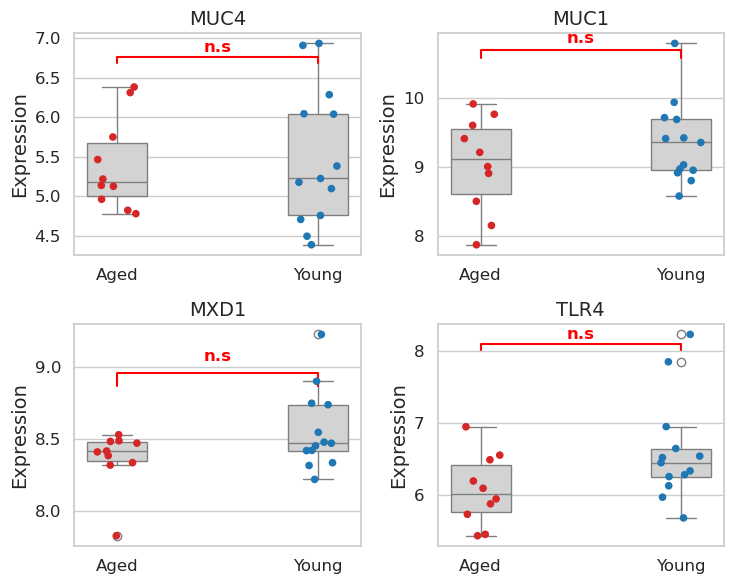

In [114]:
import pandas as pd

df = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv",
    index_col=0)

dfs = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_sample_id_age_group.csv",
    index_col=0)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

genes = ["MUC4", "MUC1", "MXD1", "TLR4"]

age_palette = {
    'Young': '#1f77b4',
    'Aged': '#d62728'
}

exclude_samples = {}

plot_list = []

common_samples = df.columns.intersection(dfs.index)
common_samples = [s for s in common_samples if s not in exclude_samples]

df_sub = df[common_samples]
dfs_sub = dfs.loc[common_samples]

for gene in genes:
    if gene not in df_sub.index:
        print(f"{gene} not found in df")
        continue
    for sample in common_samples:
        plot_list.append({
            "Gene": gene,
            "sample_id": sample,
            "Age group": dfs_sub.loc[sample, "Age group"],
            "Expression": df_sub.loc[gene, sample]
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))
axes = axes.flatten()

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene].copy()
    
    if sub_df.empty:
        print(f"{gene} has no data → skip")
        continue

    sns.boxplot(
        data=sub_df,
        x="Age group",
        y="Expression",
        width=0.3,
        color="lightgray",
        ax=ax
    )

    sns.stripplot(
        data=sub_df,
        x="Age group",
        y="Expression",
        hue="Age group",
        palette=age_palette,
        size=5.5,
        dodge=False,
        ax=ax
    )

    young = sub_df[sub_df["Age group"] == "Young"]["Expression"]
    aged = sub_df[sub_df["Age group"] == "Aged"]["Expression"]

    stat, p = ranksums(young, aged)

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "n.s"

    y_max = sub_df["Expression"].max()
    y_min = sub_df["Expression"].min()
    y = y_max + (y_max - y_min) * 0.1 - 0.5

    ax.plot([0, 0, 1, 1], [y, y*1.01, y*1.01, y], lw=1.5, c='red')
    ax.text(0.5, y*1.02, sig, ha='center', fontsize=12, fontweight='bold', color='red')

    ax.set_title(gene, fontsize=14)
    ax.set_xlabel("", fontsize=14)
    ax.set_ylabel("Expression", fontsize=14)

    ax.tick_params(axis='both', labelsize=12)

    if ax.get_legend():
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

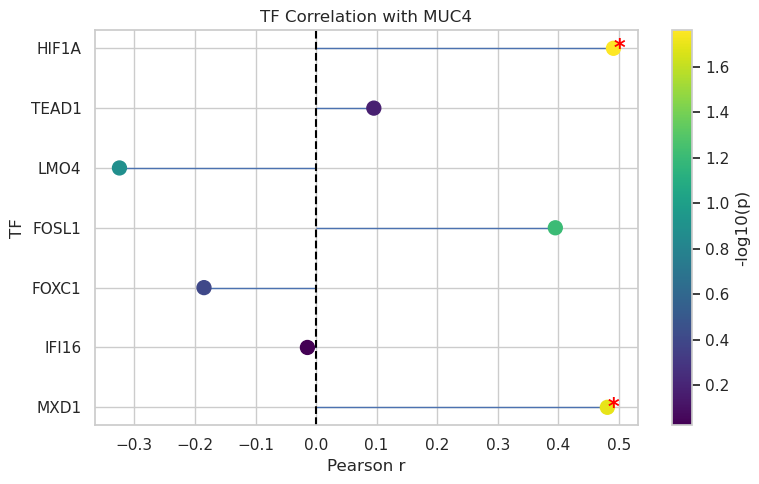

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"

exclude_samples = {}

epi = pd.read_csv(epi_path, index_col=0)
epi = epi[[s for s in epi.columns if s not in exclude_samples]]

target = "MUC4"
genes = ["MXD1", "IFI16", "FOXC1", "FOSL1", "LMO4", "TEAD1", "HIF1A"]

results = []

for g in genes:
    if g not in epi.index or target not in epi.index:
        continue
    x = epi.loc[g]
    y = epi.loc[target]
    df = pd.DataFrame({"x": x, "y": y}).fillna(0)
    r, p = pearsonr(df["x"], df["y"])
    results.append([g, r, p, -np.log10(p)])

res = pd.DataFrame(results, columns=["gene", "pearson_r", "p", "logp"])

def star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

plt.figure(figsize=(8,5))

y_pos = np.arange(len(res))

for i in range(len(res)):
    plt.hlines(
        y=y_pos[i],
        xmin=0,
        xmax=res["pearson_r"][i],
        linewidth=1
    )

sc = plt.scatter(
    res["pearson_r"],
    y_pos,
    s=100,
    c=res["logp"],
    cmap="viridis",
    zorder=3
)

for i in range(len(res)):
    plt.text(
        res["pearson_r"][i],
        y_pos[i],
        star(res["p"][i]),
        va="center",
        ha="left",
        fontsize=16,
        color="red",
        fontweight="bold"
    )

plt.yticks(y_pos, res["gene"])
plt.axvline(0, linestyle='--', color='black')
plt.xlabel("Pearson r")
plt.ylabel("TF")
plt.title("TF Correlation with MUC4")
plt.colorbar(sc, label="-log10(p)")
plt.tight_layout()
plt.show()

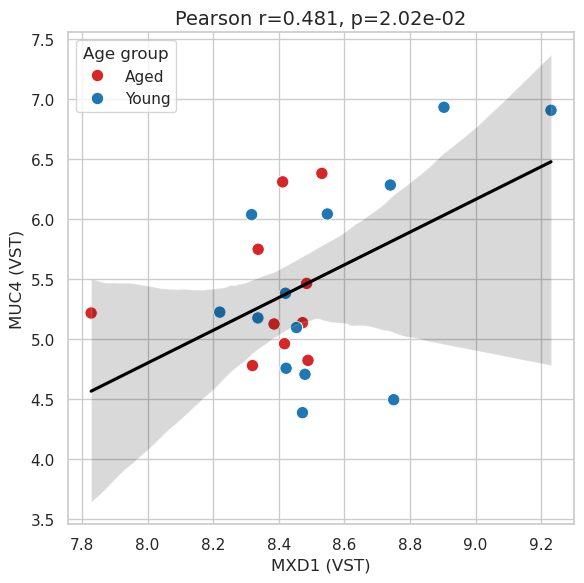

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv",
    index_col=0)

dfs = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_sample_id_age_group.csv",
    index_col=0)

common_samples = df.columns.intersection(dfs.index)

scatter_df = pd.DataFrame({
    "MXD1": df.loc["MXD1", common_samples],
    "MUC4": df.loc["MUC4", common_samples],
    "Age group": dfs.loc[common_samples, "Age group"].values
})

r, p = pearsonr(scatter_df["MXD1"], scatter_df["MUC4"])

plt.figure(figsize=(6,6))

sns.scatterplot(
    data=scatter_df,
    x="MXD1",
    y="MUC4",
    hue="Age group",
    palette={'Young': '#1f77b4', 'Aged': '#d62728'},
    s=80
)

sns.regplot(
    data=scatter_df,
    x="MXD1",
    y="MUC4",
    scatter=False,
    color="black"
)

plt.title(f"Pearson r={r:.3f}, p={p:.2e}", fontsize=14)
plt.xlabel("MXD1 (VST)")
plt.ylabel("MUC4 (VST)")

plt.tight_layout()
plt.show()

# Epithelial pySCENIC

In [61]:
adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Epithelial.h5ad")

In [62]:
adata.X = adata.layers["counts"].copy()

In [63]:
Raw_adata = adata[
    (adata.obs['Age group'] == 'Aged') &
    (adata.obs['subtype'] == 'Luminal Epithelium')
].copy()

In [64]:
genes = ["MXD1", "MUC4", "MUC1", "MYC", "TEAD1", "FOSL1"]
print(Raw_adata.shape)
[g for g in genes if g in Raw_adata.var_names]

(10954, 34756)


['MXD1', 'MUC4', 'MUC1', 'MYC', 'TEAD1', 'FOSL1']

In [65]:
import pandas as pd
import scipy.sparse
expr_matrix = Raw_adata.X
if scipy.sparse.issparse(expr_matrix):
    expr_matrix = expr_matrix.toarray()

expr_df = pd.DataFrame(expr_matrix, index=Raw_adata.obs_names, columns=Raw_adata.var_names)
expr_df.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/pySCENIC/Human/uterus_epithelial_matrix.tsv", sep="\t")

# Lymphoid subtype

In [178]:
import scanpy as sc
adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/After_Clustering.h5ad")

include_samples = {
'UA_Endo11460962_FX1170', 'UA_Endo11596522_FX1104', 'UA_Endo12061705_FX1129', 'UA_Endo12296823_EX0795', 'UA_Endo12296823_FX1119', 
'UA_Endo12296824_FX1125', 'UA_Endo12449301_FX1136', 'UA_Endo11460961_FX1097', 'UA_Endo12061415_FX1158', 'UA_Endo12061704_FX9024', 
'UA_Endo12269810_FX0033', 'UA_Endo12604667_FX1130', 'UA_Endo12865966_FX1223', 'UA_Endo10281925_FX1101', 'UA_Endo10281926_FX1101', 
'UA_Endo11282193_EX0540', 'UA_Endo11596521_FX1236', 'UA_Endo11596522_FX9005', 'UA_Endo12449299_EX0288', 'UA_Endo12449300_FX9027', 
'UA_Endo12449301_FX1150', 'UA_Endo11173480_FX0052', 'UA_Endo12449298_FX1160'    
}
adata = adata[adata.obs['Sample name'].isin(include_samples)].copy()

In [179]:
adata = adata[adata.obs['celltype_grouped'] == 'Immune - Lymphoid'].copy()

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

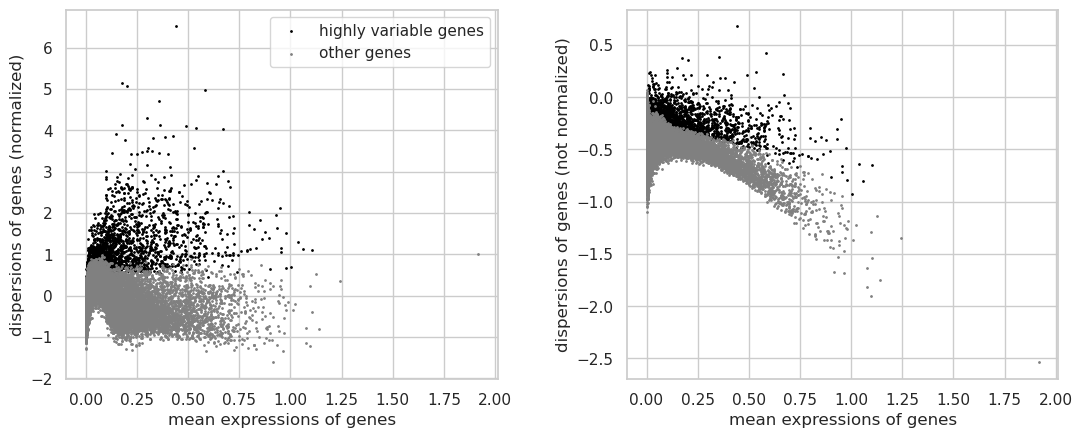

In [180]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Sample name")
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']].copy()

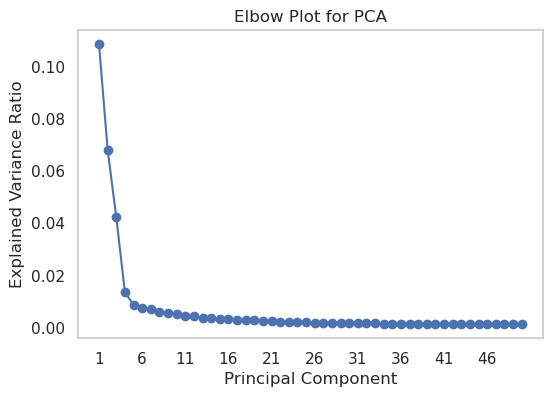

In [181]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

In [182]:
sc.tl.pca(adata, n_comps=26)

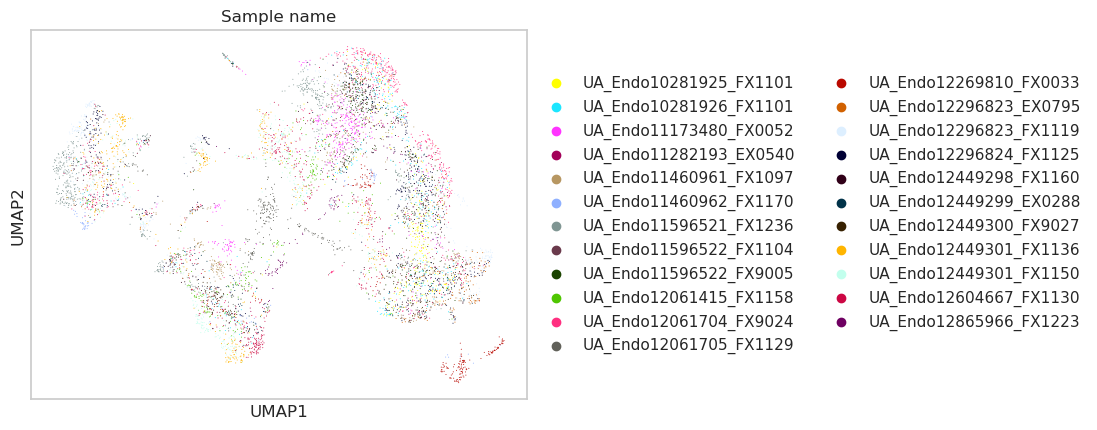

In [183]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="Sample name",
    # Setting a smaller point size to get prevent overlap
    size=2)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 270/400:  68%|██████▊   | 270/400 [02:31<01:12,  1.78it/s, v_num=1, train_loss_step=789, train_loss_epoch=780]
Monitored metric elbo_validation did not improve in the last 10 records. Best score: 806.992. Signaling Trainer to stop.


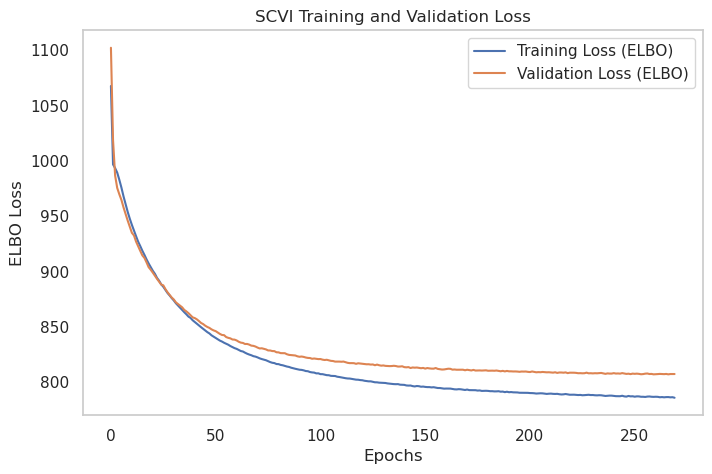

In [184]:
import scvi 
import matplotlib.pyplot as plt

scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="Sample name")
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

vae.train(max_epochs=400, early_stopping=True, early_stopping_patience=10)

train_loss = vae.history["elbo_train"]
val_loss = vae.history["elbo_validation"]
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss (ELBO)")
plt.plot(val_loss, label="Validation Loss (ELBO)")
plt.xlabel("Epochs")
plt.ylabel("ELBO Loss")
plt.title("SCVI Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

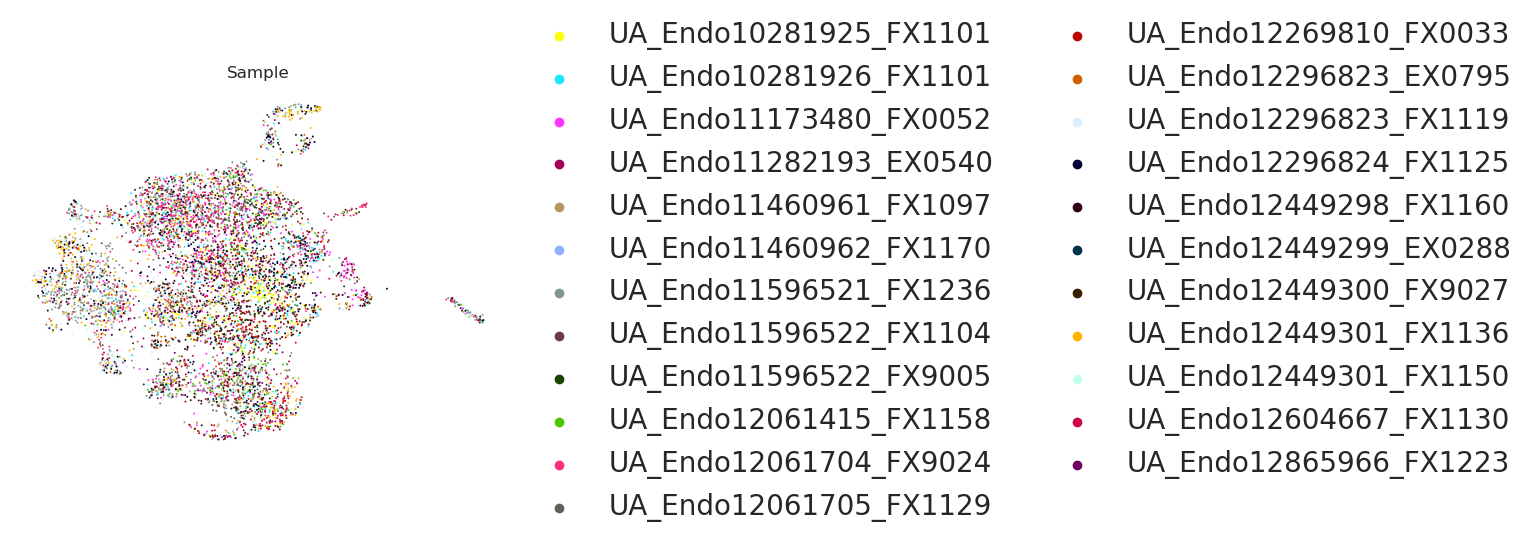

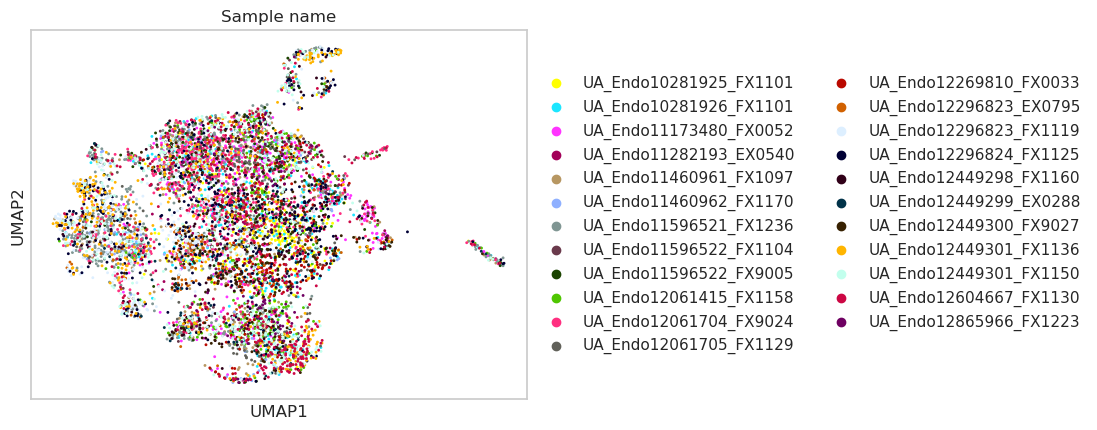

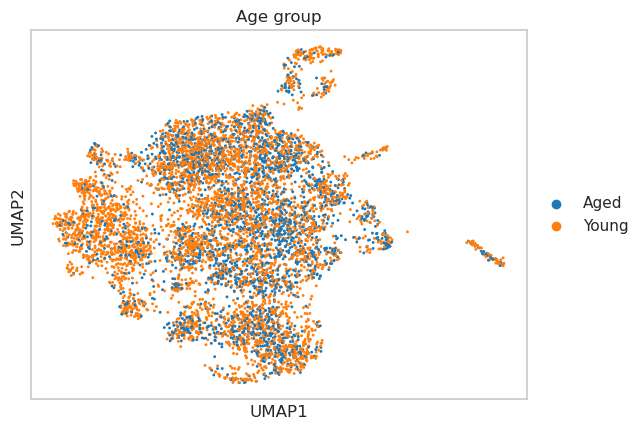

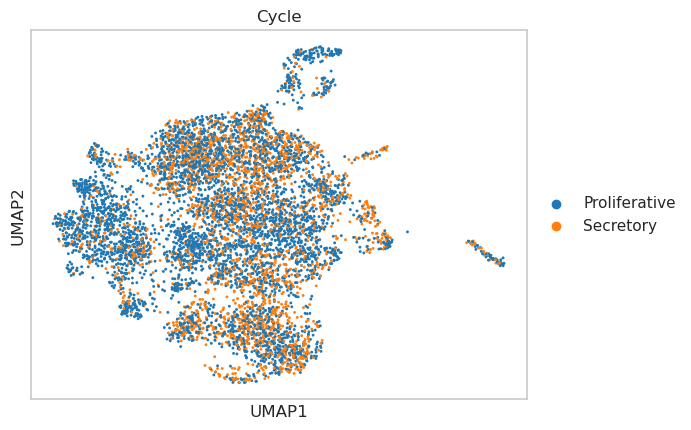

In [189]:
adata.obsm["X_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(adata, use_rep = 'X_scVI')
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=['Sample name'],
    frameon=False,
    size= 8,
    legend_fontsize=20,
    legend_fontoutline=3,
    title="Sample",
    show=False)

sc.pl.umap(adata, color=["Sample name"])
sc.pl.umap(adata, color=["Age group"])
sc.pl.umap(adata, color=["Cycle"])

Cluster 0: ['EYA2', 'MECOM', 'NPAS3', 'RHEX', 'AC024230.1', 'MAGI1', 'PLCB1', 'LINC01541', 'STX18', 'CPM']
Cluster 1: ['ESR1', 'RHEX', 'MECOM', 'EYA2', 'AC024230.1', 'DANT2', 'MAGI1', 'PARD3', 'SOX5', 'PALLD']
Cluster 2: ['RHEX', 'MECOM', 'AC024230.1', 'EYA2', 'PLCB1', 'STX18', 'MAGI1', 'LINC01541', 'UBE2D2', 'TMEM101']
Cluster 3: ['NR2F2-AS1', 'CDH11', 'DLC1', 'PALLD', 'NLGN1', 'LSAMP', 'SDK1', 'KCNIP4', 'PAMR1', 'TWIST2']
Cluster 4: ['NR2F2-AS1', 'CDH11', 'DLC1', 'AUTS2', 'SDK1', 'TSHZ3', 'ALDH1A2', 'CACNA1D', 'AOPEP', 'PALLD']
Cluster 5: ['MECOM', 'PLCB1', 'RHEX', 'EYA2', 'STX18', 'AC024230.1', 'PCDH7', 'SORBS2', 'UBE2D2', 'NSD2']
Cluster 6: ['MECOM', 'EYA2', 'RHEX', 'PTPRM', 'AC024230.1', 'KIAA1217', 'GLIS3', 'STX18', 'PTPRK', 'DCDC2']
Cluster 7: ['RHEX', 'EYA2', 'UGT2B7', 'MECOM', 'ESR1', 'NPAS3', 'CPM', 'LINC01541', 'AC024230.1', 'SGCD']
Cluster 8: ['AL136456.1', 'AFF3', 'LINC00299', 'PCDH9', 'PDZD2', 'TOX2', 'IL23R', 'PHACTR2', 'MCF2L2', 'STAC']
Cluster 9: ['DIAPH3', 'MIR924HG',

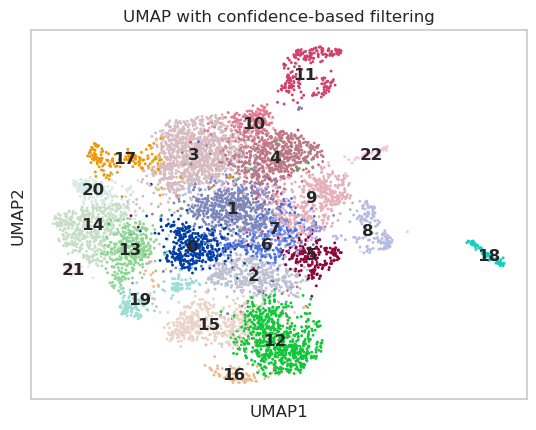

In [190]:
for res in [1,1.5,2,2.5]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

sc.tl.rank_genes_groups(adata, groupby='leiden_res_1.50', method='t-test')  # 또는 'wilcoxon'

top_genes = {}

groups = adata.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들

for group in groups:
    genes = adata.uns['rank_genes_groups']['names'][group][:10]
    top_genes[group] = genes.tolist()

for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")
sc.pl.umap(
    adata,
    color='leiden_res_1.50',
    title='UMAP with confidence-based filtering',
    legend_loc='on data')

In [192]:
del adata.varm['PCs']

In [193]:
import scanpy as sc

adata_source = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/after_QC_Before_HVG_raw.h5ad")

common_barcodes = adata.obs_names.intersection(adata_source.obs_names)

adata = adata[common_barcodes].copy()
adata_source = adata_source[common_barcodes].copy()

adata._X = adata_source.X.copy()
adata._var = adata_source.var.copy()
adata._n_vars = adata_source.n_vars
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

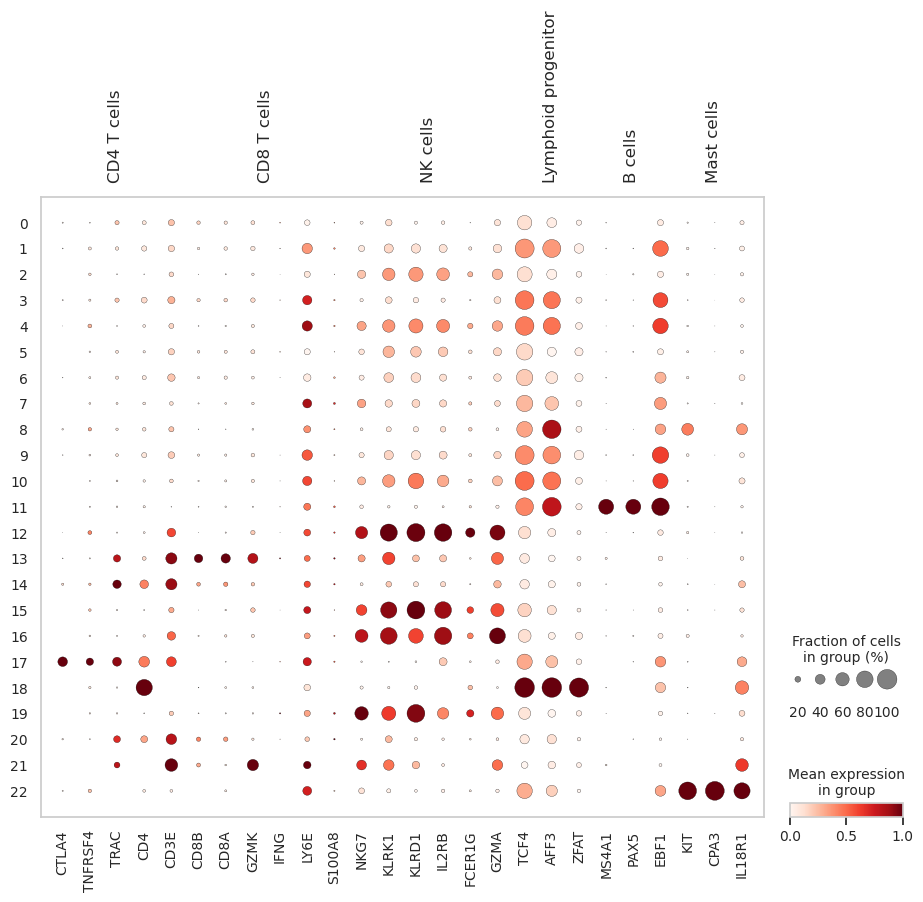

In [194]:
Epithelial_subtype_markers_human = {
    "CD4 T cells": ["CTLA4", "TNFRSF4", "TRAC", "CD4", "CD3E"],
    "CD8 T cells": ["CD8B", "CD8A", "GZMK", "IFNG", "LY6E","S100A8"],
    "NK cells": ["NKG7", "KLRK1", "KLRD1", "IL2RB", "FCER1G", "GZMA"],
    "Lymphoid progenitor": ["TCF4", "AFF3","ZFAT"],
    "B cells": ['MS4A1', 'PAX5', 'EBF1'],
    "Mast cells": ['KIT', 'CPA3', 'IL18R1']}

existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in adata.var_names]
    for subtype, genes in Epithelial_subtype_markers_human.items()}

sc.pl.dotplot(
    adata,
    var_names=existing_subtype_markers,
    groupby="leiden_res_1.50",
    standard_scale="var",
    dendrogram=False)

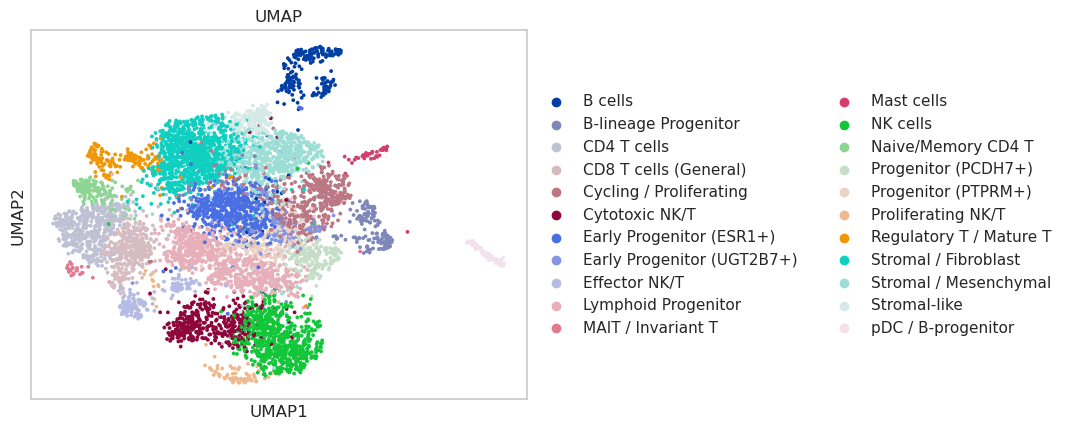

Cluster B cells: ['ARHGAP24', 'BANK1', 'RALGPS2', 'AFF3', 'MEF2C', 'MS4A1', 'FCHSD2', 'CD74', 'PAX5', 'ADAM28', 'EBF1', 'AC120193.1', 'MARCH1', 'CDK14', 'LINC00926', 'FCRL1', 'BLK', 'GNG7', 'BCL11A', 'WDFY4']
Cluster B-lineage Progenitor: ['AL136456.1', 'AFF3', 'LINC00299', 'PCDH9', 'PDZD2', 'TOX2', 'IL23R', 'PHACTR2', 'MCF2L2', 'STAC', 'ARHGAP10', 'KIT', 'HDAC9', 'LDLRAD3', 'AHR', 'IKZF2', 'LPAR1', 'BICC1', 'ST6GALNAC3', 'UNC5C']
Cluster CD4 T cells: ['ARHGAP15', 'BCL11B', 'PTPRC', 'MBNL1', 'CAMK4', 'IL7R', 'TNFAIP8', 'RIPOR2', 'THEMIS', 'ANKRD44', 'ETS1', 'MT-CO1', 'IKZF1', 'TC2N', 'PRKCQ', 'SYNE2', 'ELMO1', 'CD2', 'EMB', 'B2M']
Cluster CD8 T cells (General): ['PTPRC', 'ARHGAP15', 'BCL11B', 'THEMIS', 'FYN', 'AOAH', 'ANKRD44', 'PRKCH', 'MBNL1', 'PRKCB', 'CD2', 'FYB1', 'CDC42SE2', 'LINC00861', 'TOX', 'PITPNC1', 'TC2N', 'APBB1IP', 'ELMO1', 'TNFAIP8']
Cluster Cycling / Proliferating: ['DIAPH3', 'MIR924HG', 'SDK1', 'PALLD', 'KCNIP4', 'LSAMP', 'NLGN1', 'LINC01572', 'CENPP', 'AP001347.1', '

In [198]:
cluster_to_group = {
    0: "Lymphoid Progenitor",        # EYA2, MECOM, RHEX
    1: "Early Progenitor (ESR1+)",   # ESR1, MECOM, RHEX
    2: "Lymphoid Progenitor",        # RHEX, MECOM, EYA2
    3: "Stromal / Fibroblast",       # CDH11, NR2F2-AS1, PALLD
    4: "Stromal / Mesenchymal",      # CDH11, NR2F2-AS1, ALDH1A2
    5: "Progenitor (PCDH7+)",        # MECOM, PCDH7, SORBS2
    6: "Progenitor (PTPRM+)",        # MECOM, EYA2, PTPRM
    7: "Early Progenitor (UGT2B7+)", # RHEX, EYA2, UGT2B7
    8: "B-lineage Progenitor",       # AFF3, TOX2, IL23R
    9: "Cycling / Proliferating",    # DIAPH3, CENPP (분열 중인 세포)
    10: "Stromal-like",              # CDH11, NR2F2-AS1, LDB2
    11: "B cells",                   # MS4A1, BANK1, PAX5, CD74
    12: "NK cells",                  # NCAM1, GNLY, KLRC1, ITGAX
    13: "CD8 T cells (General)",         # BCL11B, PTPRC, THEMIS, FYN
    14: "CD4 T cells",               # IL7R, BCL11B, PTPRC
    15: "Cytotoxic NK/T",            # NCAM1, TXK, KLRD1, CD96
    16: "Proliferating NK/T",        # DOCK10, SMC4, NCAM1, CENPP
    17: "Regulatory T / Mature T",   # IKZF2(Helios), IL2RA(CD25), TOX
    18: "pDC / B-progenitor",        # TCF4, BCL11A, AFF3
    19: "Effector NK/T",             # CD247, KLRF1, KLRD1, ZEB2
    20: "Naive/Memory CD4 T",        # IL7R, FOXP1, LEF1, CAMK4
    21: "MAIT / Invariant T",        # SLC4A10, IL7R, RIPOR2
    22: "Mast cells",                # CPA3, KIT, HPGDS, SLC18A2
}

adata.obs["subtype"] = adata.obs["leiden_res_1.50"].astype(int).map(cluster_to_group)
sc.pl.umap(
    adata,
    color='subtype',
    title='UMAP',
    s = 30)

sc.tl.rank_genes_groups(adata, groupby='subtype', method='t-test')  # 또는 'wilcoxon'
top_genes = {}
groups = adata.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들
for group in groups:
    genes = adata.uns['rank_genes_groups']['names'][group][:20]
    top_genes[group] = genes.tolist()


for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")

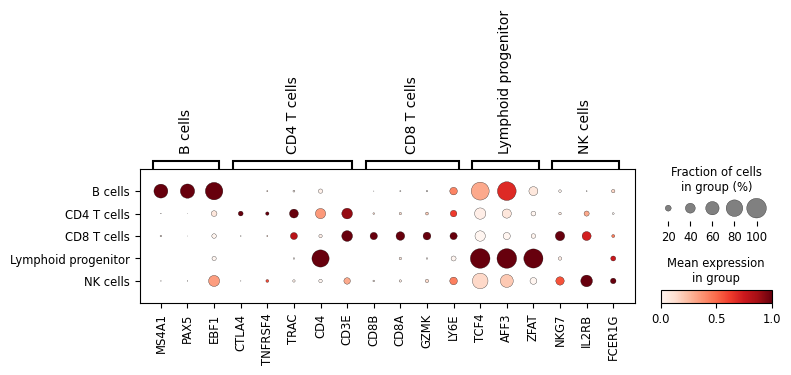

In [6]:
Epithelial_subtype_markers_human = {
    "B cells": ['MS4A1', 'PAX5', 'EBF1'],
    "CD4 T cells": ["CTLA4", "TNFRSF4", "TRAC", "CD4", "CD3E"],
    "CD8 T cells": ["CD8B", "CD8A", "GZMK", "LY6E"],
    "Lymphoid progenitor": ["TCF4", "AFF3","ZFAT"],
    "NK cells": ["NKG7", "IL2RB", "FCER1G"]}

existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in adata.var_names]
    for subtype, genes in Epithelial_subtype_markers_human.items()}

sc.pl.dotplot(
    adata,
    var_names=existing_subtype_markers,
    groupby="subtype",
    standard_scale="var",
    dendrogram=False)

In [141]:
adata

AnnData object with n_obs × n_vars = 7027 × 34694
    obs: 'Sample name', 'Organism', 'Individual', 'Developmental stage', 'Sex', 'Organism part', 'Disease', 'Cycle', 'Age', 'Age group', 'Dataset', 'Hormonal treatment', 'Endometriosis stage', '10x technology', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden_res_0.25', 'leiden_res_0.50', 'leiden_res_0.75', 'leiden_res_1.00', 'celltype_grouped', 'leiden_res_1.50', 'leiden_res_2.00', 'leiden_res_2.50', 'subtype', 'Each mouse'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', '

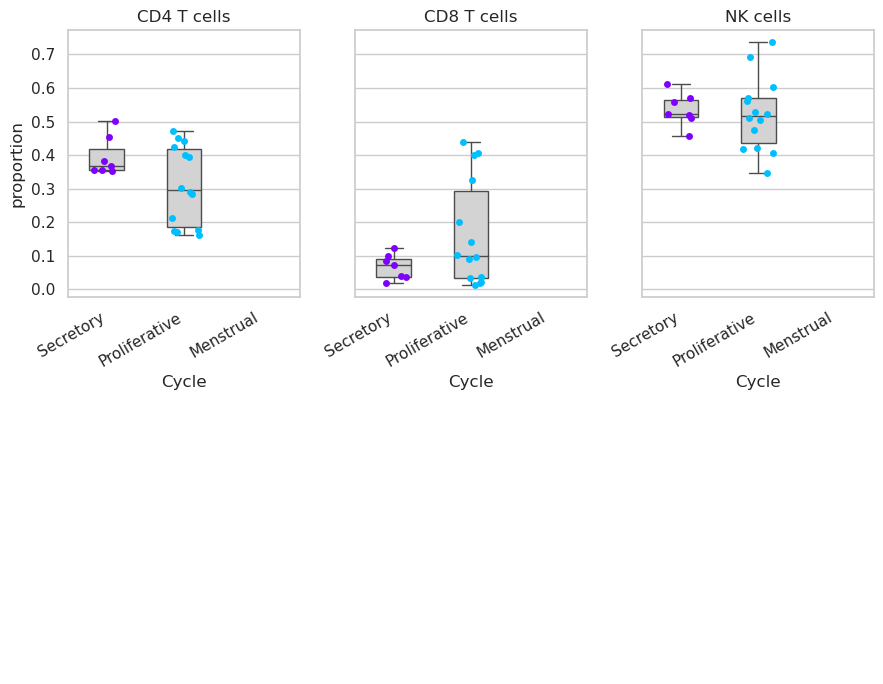

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
import warnings

del adata.varm['PCs']

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

clin_palette = {
    'Secretory': '#8000ff',
    'Proliferative': '#00bfff',
    'Menstrual': '#ff8c00'
}

adata.obs['Each mouse'] = adata.obs['Individual']

adata_filtered = adata[adata.obs['Organism part'] != 'spleen'].copy()
adata_filtered = adata_filtered[
    adata_filtered.obs['Cycle'].isin(['Secretory','Proliferative','Menstrual'])
]

group_order = ['Secretory', 'Proliferative', 'Menstrual']

subtypes = sorted(adata_filtered.obs['subtype'].dropna().unique())

def normalize_mouse(df):
    total = df['count'].sum()
    df['proportion'] = df['count'] / total if total > 0 else 0
    return df

mouse_props_list = []

for (mouse, cycle), grp_df in adata_filtered.obs.groupby(['Each mouse','Cycle']):
    count_df = grp_df.groupby('subtype').size().reset_index(name='count')
    count_df['Each mouse'] = mouse
    count_df['Cycle'] = cycle
    mouse_props_list.append(normalize_mouse(count_df))

mouse_props = pd.concat(mouse_props_list, ignore_index=True)

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3.5*n_rows), sharey=True)
axes = axes.flatten()

for i, subtype in enumerate(subtypes):
    ax = axes[i]

    data_sub = mouse_props[mouse_props['subtype'] == subtype]

    sns.boxplot(
        x='Cycle', y='proportion', data=data_sub, ax=ax,
        order=group_order,
        boxprops={'facecolor': 'lightgray'},
        fliersize=0,
        width=0.45
    )

    for cond in data_sub['Cycle'].unique():
        sub_df = data_sub[data_sub['Cycle'] == cond]
        sns.stripplot(
            x='Cycle', y='proportion', data=sub_df,
            color=clin_palette.get(cond, 'black'),
            jitter=0.2,
            size=5,
            ax=ax,
            order=group_order
        )

    pairs = [
        ('Secretory','Proliferative'),
        ('Secretory','Menstrual'),
        ('Proliferative','Menstrual')
    ]

    for j, (g1, g2) in enumerate(pairs):
        v1 = data_sub[data_sub['Cycle'] == g1]['proportion']
        v2 = data_sub[data_sub['Cycle'] == g2]['proportion']

        if len(v1) > 0 and len(v2) > 0:
            _, p = ranksums(v1, v2)
            if p < 0.05:
                x1, x2 = group_order.index(g1), group_order.index(g2)
                y = 1.05 + j * 0.05
                ax.plot([x1, x1, x2, x2], [y, y+0.01, y+0.01, y], c='red')
                ax.text((x1+x2)/2, y+0.015, "*", ha='center', color='red')

    ax.set_title(subtype)
    ax.set_xticklabels(group_order, rotation=30, ha='right')

for j in range(len(subtypes), n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

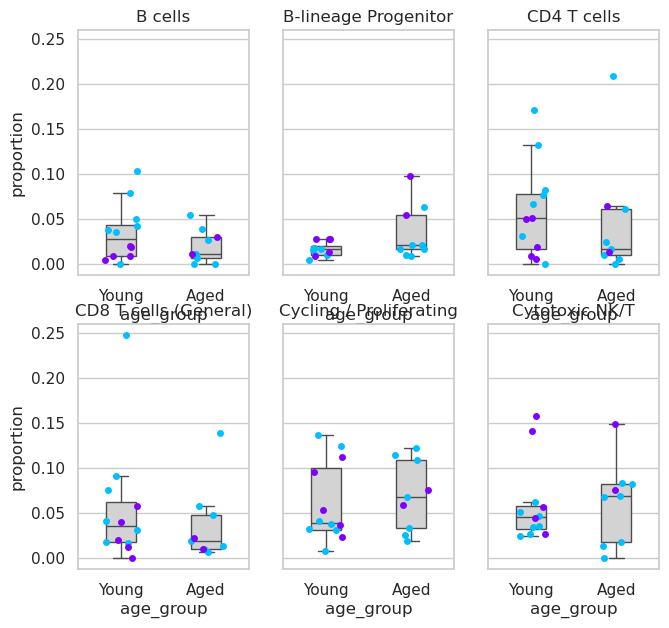

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
import warnings

#del adata.varm['PCs']

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

clin_palette = {
    'Secretory': '#8000ff',
    'Proliferative': '#00bfff',
    'Menstrual': '#ff8c00'
}

adata.obs['Each mouse'] = adata.obs['Individual']
adata.obs['age_num'] = pd.to_numeric(adata.obs['Age'], errors='coerce')

def assign_age_group(row):
    age = row['age_num']
    if age >= 35:
        return 'Aged'
    else:
        return 'Young'

adata.obs['age_group'] = adata.obs.apply(assign_age_group, axis=1)

adata_filtered = adata[adata.obs['Organism part'] != 'spleen'].copy()
adata_filtered = adata_filtered[adata_filtered.obs['Cycle'].isin(['Secretory','Proliferative','Menstrual'])]

group_order = ['Young', 'Aged']

subtypes = sorted(adata_filtered.obs['subtype'].dropna().unique())

def normalize_mouse(df):
    total = df['count'].sum()
    df['proportion'] = df['count'] / total if total > 0 else 0
    return df

mouse_props_list = []

for (mouse, age_group), grp_df in adata_filtered.obs.groupby(['Each mouse','age_group']):
    count_df = grp_df.groupby('subtype').size().reset_index(name='count')
    count_df['Each mouse'] = mouse
    count_df['age_group'] = age_group
    count_df['Cycle'] = grp_df['Cycle'].iloc[0]
    mouse_props_list.append(normalize_mouse(count_df))

mouse_props = pd.concat(mouse_props_list, ignore_index=True)

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 3.5*n_rows), sharey=True)

axes = axes.flatten()

for i, subtype in enumerate(subtypes):
    ax = axes[i]

    data_sub = mouse_props[mouse_props['subtype'] == subtype]

    sns.boxplot(
        x='age_group', y='proportion', data=data_sub, ax=ax,
        order=group_order,
        boxprops={'facecolor': 'lightgray'},
        fliersize=0,
        width=0.35
    )

    for cycle in data_sub['Cycle'].unique():
        sub_df = data_sub[data_sub['Cycle'] == cycle]
        sns.stripplot(
            x='age_group', y='proportion', data=sub_df,
            color=clin_palette.get(cycle, 'black'),
            jitter=0.2,
            size=5,
            ax=ax,
            order=group_order
        )

    v1 = data_sub[data_sub['age_group'] == 'Young']['proportion']
    v2 = data_sub[data_sub['age_group'] == 'Aged']['proportion']

    if len(v1) > 0 and len(v2) > 0:
        _, p = ranksums(v1, v2)
        if p < 0.05:
            ax.plot([0, 0, 1, 1], [1.05, 1.06, 1.06, 1.05], c='red')
            ax.text(0.5, 1.065, "*", ha='center', color='red')

    ax.set_title(subtype)

for j in range(len(subtypes), n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [177]:
for subtype in subtypes:
    data_sub = mouse_props[mouse_props['subtype'] == subtype]

    if subtype == "CD8 T cells":
        v1 = data_sub[data_sub['age_group'] == 'Young']['proportion']
        v2 = data_sub[data_sub['age_group'] == 'Aged']['proportion']

        if len(v1) > 0 and len(v2) > 0:
            _, p = ranksums(v1, v2)
            print("CD8 T cell p-value:", p)

CD8 T cell p-value: 0.6698153575994166


In [146]:
adata.write("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Lymphoid.h5ad")

In [30]:
################################
############ DEseq #############
################################

In [42]:
import scanpy as sc
Lymphoid = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Lymphoid.h5ad")

In [43]:
Lymphoid.X = Lymphoid.layers['counts']
adata = Lymphoid[Lymphoid.obs['subtype'] == 'CD8 T cells'].copy()

import pandas as pd
import os

outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/"
os.makedirs(outdir, exist_ok=True)
counts = adata.X
genes = adata.var_names
for mc in adata.obs["subtype"].unique():
    ad = adata[adata.obs["subtype"] == mc]
    
    mat = ad.X
    df = pd.DataFrame(
        mat.T.toarray() if hasattr(mat, "toarray") else mat.T,
        index=genes, columns=ad.obs_names)
    
    pb = df.groupby(ad.obs["Sample name"], axis=1).sum()
    pb.to_csv(f"{outdir}/pseudobulk_module_cluster_{mc}.csv")

In [44]:
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected"
os.makedirs(outdir, exist_ok=True)

df = (
    adata.obs[["Sample name", "Cycle","Age group","Disease"]]
    .drop_duplicates()
    .sort_values("Sample name"))
df.to_csv(f"{outdir}/CD8_sample_id_age_group.csv", index=False)

In [56]:
import pandas as pd

df = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv",
    index_col=0)

dfs = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8_sample_id_age_group.csv",
    index_col=0)

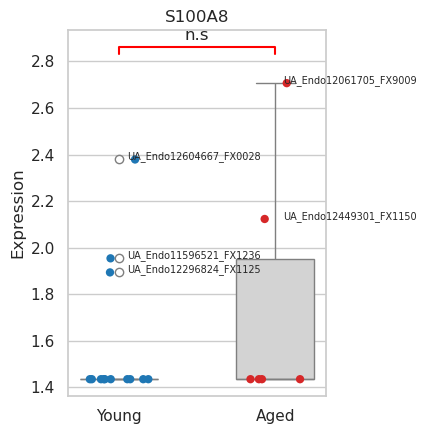

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

genes = ["S100A8"]

age_palette = {
    'Young': '#1f77b4',
    'Aged': '#d62728'
}

plot_list = []

common_samples = df.columns.intersection(dfs.index)

df_sub = df[common_samples]
dfs_sub = dfs.loc[common_samples]

for gene in genes:
    if gene not in df_sub.index:
        continue

    for sample in common_samples:
        plot_list.append({
            "Gene": gene,
            "sample_id": sample,
            "Age group": dfs_sub.loc[sample, "Age group"],
            "Expression": df_sub.loc[gene, sample]
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(4.3 * len(genes), 4.5))

if len(genes) == 1:
    axes = [axes]

group_order = ["Young", "Aged"]
x_map = {g: i for i, g in enumerate(group_order)}

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.boxplot(
        data=sub_df,
        x="Age group",
        y="Expression",
        order=group_order,
        color="lightgray",
        ax=ax,
        width=0.5
    )

    sns.stripplot(
        data=sub_df,
        x="Age group",
        y="Expression",
        hue="Age group",
        palette=age_palette,
        size=6,
        jitter=0.2,
        dodge=False,
        order=group_order,
        ax=ax
    )

    label_df = sub_df[sub_df["Expression"] >= 1.5]

    for _, row in label_df.iterrows():
        x_pos = x_map[row["Age group"]]
        y_pos = row["Expression"]
        ax.text(x_pos + 0.05, y_pos, row["sample_id"], fontsize=7)

    young = sub_df[sub_df["Age group"] == "Young"]["Expression"]
    aged = sub_df[sub_df["Age group"] == "Aged"]["Expression"]

    stat, p = ranksums(young, aged)

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "n.s"

    y_max = sub_df["Expression"].max()
    y_min = sub_df["Expression"].min()
    y = y_max + (y_max - y_min) * 0.1

    ax.plot([0, 0, 1, 1], [y, y*1.01, y*1.01, y], lw=1.5, c='red')
    ax.text(0.5, y*1.02, sig, ha='center')

    ax.set_title(gene)
    ax.set_xlabel("")
    ax.set_ylabel("Expression")

    if ax.get_legend():
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [60]:
dfs

,Cycle,Age group,Disease
Sample name,,,
UA_Endo11460963_FX9006,Proliferative,Young,endometriosis
UA_Endo11596521_FX1236,Proliferative,Young,endometriosis
UA_Endo11596522_FX1104,Proliferative,Young,endometriosis
UA_Endo12061415_FX1158,Secretory,Young,endometriosis
UA_Endo12061415_FX1223,Menstrual,Aged,endometriosis
UA_Endo12061704_FX1163,Proliferative,Aged,normal
UA_Endo12061705_FX9009,Menstrual,Aged,normal
UA_Endo12269810_FX0033,Secretory,Young,endometriosis
UA_Endo12269811_FX0060,Proliferative,Young,endometriosis


In [47]:
threshold = 1.5

for gene in genes:
    if gene not in df_sub.index:
        continue

    sub_df = plot_df[plot_df["Gene"] == gene]
    label_df = sub_df[sub_df["Expression"] >= threshold]

    if not label_df.empty:
        print(f"\n=== {gene} | Expression >= {threshold} ===")
        print(label_df[["sample_id", "Age group", "Expression"]].sort_values(by="Expression", ascending=False))


=== S100A8 | Expression >= 1.5 ===
                 sample_id Age group  Expression
1   UA_Endo12061705_FX9009      Aged    2.706328
16  UA_Endo12604667_FX0028     Young    2.378638
11  UA_Endo12449301_FX1150      Aged    2.123243
3   UA_Endo11596521_FX1236     Young    1.954328
8   UA_Endo12296824_FX1125     Young    1.893901


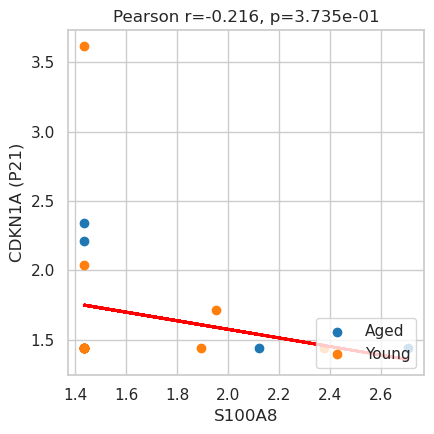

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

df = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv",
    index_col=0)

dfs = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8_sample_id_age_group.csv",
    index_col=0)

common_samples = df.columns.intersection(dfs.index)
df_sub = df[common_samples]
dfs_sub = dfs.loc[common_samples]

age_groups = dfs_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

x = df_sub.loc["S100A8"]
y = df_sub.loc["CDKN1A"]

pearson_r, pearson_p = pearsonr(x, y)

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = dfs_sub[dfs_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("S100A8")
plt.ylabel("CDKN1A (P21)")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

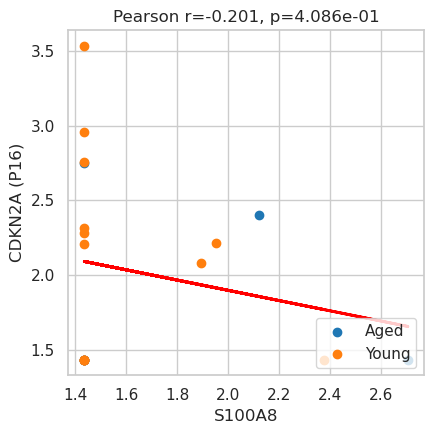

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

df = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv",
    index_col=0)

dfs = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8_sample_id_age_group.csv",
    index_col=0)

common_samples = df.columns.intersection(dfs.index)
df_sub = df[common_samples]
dfs_sub = dfs.loc[common_samples]

age_groups = dfs_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

x = df_sub.loc["S100A8"]
y = df_sub.loc["CDKN2A"]

pearson_r, pearson_p = pearsonr(x, y)

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = dfs_sub[dfs_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("S100A8")
plt.ylabel("CDKN2A (P16)")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

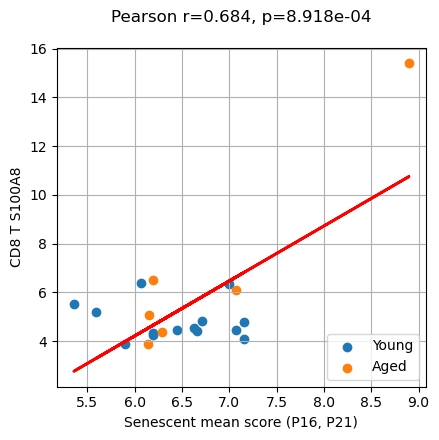

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

cd8_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"
epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv"
meta_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/sample_id_age_group.csv"

exclude_samples = {

}

cd8 = pd.read_csv(cd8_path, index_col=0)
epi = pd.read_csv(epi_path, index_col=0)
meta = pd.read_csv(meta_path, index_col=0)

all_samples = cd8.columns.union(epi.columns)
all_samples = [s for s in all_samples if s not in exclude_samples]

cd8 = cd8.reindex(columns=all_samples, fill_value=0)
epi = epi.reindex(columns=all_samples, fill_value=0)
meta_sub = meta.loc[all_samples]

x = (cd8.loc["CDKN2A"] + cd8.loc["CDKN1A"])/2
y = cd8.loc["S100A8"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

age_groups = meta_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = meta_sub[meta_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("Senescent mean score (P16, P21)")
plt.ylabel("CD8 T S100A8")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}\n")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Total subtype merge

In [24]:
import scanpy as sc
import pandas as pd

adata_full = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Total_selected.h5ad")
adata_lymphoid = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Lymphoid.h5ad")
adata_epi = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/Epithelial.h5ad")

adata_full.varm = {}
adata_full.obsm = {}
adata_full.uns = {}

selected_subtypes = pd.concat([adata_lymphoid.obs[['subtype']], adata_epi.obs[['subtype']]])
common_cells = adata_full.obs.index.intersection(selected_subtypes.index)
adata_full = adata_full[common_cells].copy()
adata_full.obs['subtype'] = selected_subtypes.loc[common_cells, 'subtype']

adata_full.write_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/After_Clustering_with_subtype.h5ad")

In [25]:
adata_full = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/h5ad/selected/After_Clustering_with_subtype.h5ad")

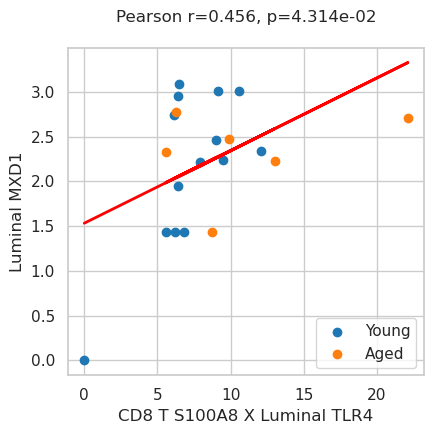

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

cd8_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"
epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv"
meta_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/sample_id_age_group.csv"

exclude_samples = {

}

cd8 = pd.read_csv(cd8_path, index_col=0)
epi = pd.read_csv(epi_path, index_col=0)
meta = pd.read_csv(meta_path, index_col=0)

all_samples = cd8.columns.union(epi.columns)
all_samples = [s for s in all_samples if s not in exclude_samples]

cd8 = cd8.reindex(columns=all_samples, fill_value=0)
epi = epi.reindex(columns=all_samples, fill_value=0)
meta_sub = meta.loc[all_samples]

x = cd8.loc["S100A8"] * epi.loc["TLR4"]
y = epi.loc["MXD1"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

age_groups = meta_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = meta_sub[meta_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("CD8 T S100A8 X Luminal TLR4")
plt.ylabel("Luminal MXD1")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}\n")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

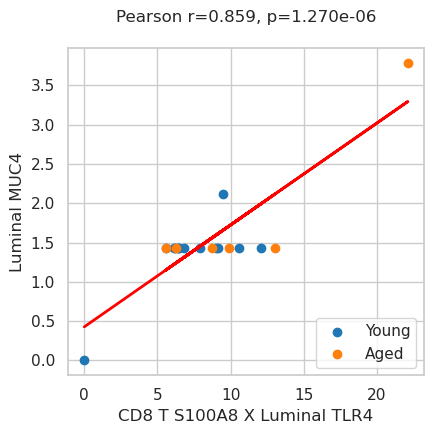

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

cd8_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"
epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv"
meta_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/sample_id_age_group.csv"

exclude_samples = {}

cd8 = pd.read_csv(cd8_path, index_col=0)
epi = pd.read_csv(epi_path, index_col=0)
meta = pd.read_csv(meta_path, index_col=0)

all_samples = cd8.columns.union(epi.columns)
all_samples = [s for s in all_samples if s not in exclude_samples]

cd8 = cd8.reindex(columns=all_samples, fill_value=0)
epi = epi.reindex(columns=all_samples, fill_value=0)
meta_sub = meta.loc[all_samples]

x = cd8.loc["S100A8"] * epi.loc["TLR4"]
y = epi.loc["MUC4"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

age_groups = meta_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = meta_sub[meta_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("CD8 T S100A8 X Luminal TLR4")
plt.ylabel("Luminal MUC4")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}\n")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

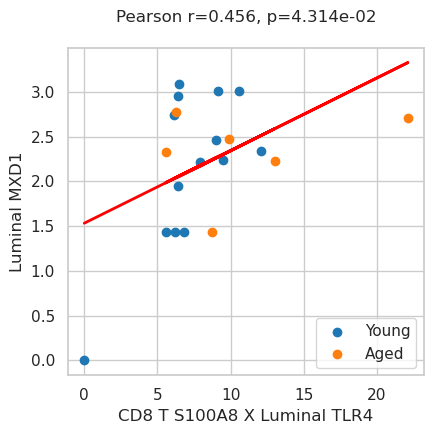

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

cd8_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"
epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv"
meta_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/sample_id_age_group.csv"

exclude_samples = {

}

cd8 = pd.read_csv(cd8_path, index_col=0)
epi = pd.read_csv(epi_path, index_col=0)
meta = pd.read_csv(meta_path, index_col=0)

all_samples = cd8.columns.union(epi.columns)
all_samples = [s for s in all_samples if s not in exclude_samples]

cd8 = cd8.reindex(columns=all_samples, fill_value=0)
epi = epi.reindex(columns=all_samples, fill_value=0)
meta_sub = meta.loc[all_samples]

x = cd8.loc["S100A8"] * epi.loc["TLR4"]
y = epi.loc["MXD1"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

age_groups = meta_sub['Age group'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = meta_sub[meta_sub['Age group']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("CD8 T S100A8 X Luminal TLR4")
plt.ylabel("Luminal MXD1")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}\n")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

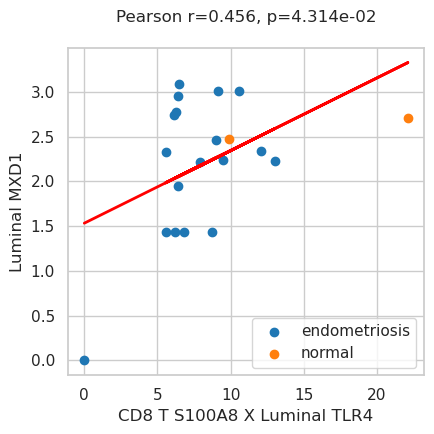

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

cd8_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/Luminal_bulk_rna_vsd_preprocess.csv"
epi_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/selected/CD8T_bulk_rna_vsd_preprocess.csv"
meta_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Human/DESeq2/sample_id_age_group.csv"

exclude_samples = {

}

cd8 = pd.read_csv(cd8_path, index_col=0)
epi = pd.read_csv(epi_path, index_col=0)
meta = pd.read_csv(meta_path, index_col=0)

all_samples = cd8.columns.union(epi.columns)
all_samples = [s for s in all_samples if s not in exclude_samples]

cd8 = cd8.reindex(columns=all_samples, fill_value=0)
epi = epi.reindex(columns=all_samples, fill_value=0)
meta_sub = meta.loc[all_samples]

x = cd8.loc["S100A8"] * epi.loc["TLR4"]
y = epi.loc["MXD1"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

age_groups = meta_sub['Disease'].unique()
colors = plt.cm.tab10(range(len(age_groups)))
age_color_dict = dict(zip(age_groups, colors))

plt.figure(figsize=(4.5,4.5))
for age in age_groups:
    samples = meta_sub[meta_sub['Disease']==age].index
    plt.scatter(x[samples], y[samples], label=age, color=age_color_dict[age])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='_nolegend_')

plt.xlabel("CD8 T S100A8 X Luminal TLR4")
plt.ylabel("Luminal MXD1")
plt.title(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}\n")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
dfs

,Cycle,Age group,Disease
Sample name,,,
UA_Endo11460963_FX9006,Proliferative,Young,endometriosis
UA_Endo11596521_FX1236,Proliferative,Young,endometriosis
UA_Endo11596522_FX1104,Proliferative,Young,endometriosis
UA_Endo12061415_FX1158,Secretory,Young,endometriosis
UA_Endo12061415_FX1223,Menstrual,Aged,endometriosis
UA_Endo12061704_FX1163,Proliferative,Aged,normal
UA_Endo12061705_FX9009,Menstrual,Aged,normal
UA_Endo12269810_FX0033,Secretory,Young,endometriosis
UA_Endo12269811_FX0060,Proliferative,Young,endometriosis
